# PPO Portfolio Optimization: Paper-Faithful, Robust, and Legacy Surprise

This experiment compares alternative Surprise reward definitions using the exact
**real-data PPO control** from `FinRL_PortfolioOptimization_PPO_Synthetic_vs_Real`.

All variants use the same real data, per-ticker price scaling, 50-day EIIE
observation, `MultiInputPolicy`, PPO hyperparameters, **0.25% transaction cost**,
seeds, validation schedule, and external-reward backtest. The reward supplied to PPO
during training is the only experimental difference.


## Experimental protocol

The half-open periods and training settings match the Real-vs-Synthetic experiment:

| Block | Period | Purpose |
|---|---|---|
| Train | 2024-01-01 to 2024-10-01 | Fit the policy and real-data scaler |
| Validation | 2024-10-01 to 2025-01-01 | Select checkpoints using external reward |
| Test | 2025-01-01 to 2026-01-01 | Final untouched real-data comparison |

Only the original `with_fee=0.0025` condition is run. Formal mode therefore contains
`6 reward variants × 1 commission setting × 3 seeds = 18 runs`. Validation and every
reported financial metric use the original scaled log-return reward only. Intrinsic
reward is training-only.


In [1]:
from __future__ import annotations

import glob
import os
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import Image as NotebookImage
from stable_baselines3 import PPO
from tqdm.auto import tqdm


def _bootstrap_project_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "finrl").is_dir() and (candidate / "examples").is_dir():
            return candidate
    raise RuntimeError("Could not locate the FinRL project root.")


PROJECT_ROOT = _bootstrap_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from finrl.experiments.notebook_utils import check_calendar_coverage
from finrl.experiments.notebook_utils import environment_flag
from finrl.experiments.notebook_utils import read_real_ohlcv_csvs
from finrl.experiments.portfolio_intrinsic import evaluate_portfolio_periods
from finrl.experiments.portfolio_intrinsic import plan_portfolio_training
from finrl.experiments.portfolio_intrinsic import portfolio_environment_kwargs
from finrl.experiments.portfolio_intrinsic import portfolio_ppo_kwargs
from finrl.experiments.portfolio_intrinsic import prepare_real_portfolio_periods
from finrl.experiments.portfolio_intrinsic import resolve_variant_reward_config
from finrl.experiments.portfolio_intrinsic import train_portfolio_variant
from finrl.experiments.portfolio_intrinsic import VARIANT_WEIGHTS
from finrl.experiments.stock_intrinsic import plot_intrinsic_diagnostics
from finrl.experiments.stock_intrinsic import plot_learning_curves_by_variant
from finrl.experiments.stock_intrinsic import plot_period_equity_comparison
from finrl.experiments.stock_intrinsic import plot_sharpe_seed_selection
from finrl.experiments.stock_intrinsic import plot_test_metric_comparison
from finrl.experiments.stock_intrinsic import plot_test_portfolio_weights
from finrl.meta.env_portfolio_optimization.env_portfolio_optimization_gymnasium import (
    PortfolioOptimizationGymnasiumEnv,
)

warnings.filterwarnings("once")
DEVICE = os.getenv("FINRL_DEVICE", "cpu")
torch.set_num_threads(int(os.getenv("FINRL_TORCH_NUM_THREADS", "1")))
print("project root:", PROJECT_ROOT)
print("device:", DEVICE)


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/opt/anaconda3/envs/finrl_exp/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


project root: /home/cwei1213/FinRL_Exp
device: cpu


## 1. Configuration


In [2]:
REAL_DATA_GLOB = os.getenv("FINRL_REAL_DATA_GLOB", "data/real/*.csv")
RESULT_ROOT = Path(
    os.getenv(
        "FINRL_INTRINSIC_RESULT_ROOT",
        str(PROJECT_ROOT / "results" / "ppo_portfolio_intrinsic_reward_ablation"),
    )
).resolve()

TRAIN_START, TRAIN_END = "2024-01-01", "2024-10-01"
VALIDATION_START, VALIDATION_END = "2024-10-01", "2025-01-01"
TEST_START, TEST_END = "2025-01-01", "2026-01-01"
EXPECTED_TICKERS = ["AAPL", "AMZN", "GOOGL", "MSFT", "NVDA"]
PRICE_COLUMNS = ["close", "high", "low"]
TIME_WINDOW = 50
INITIAL_AMOUNT = 100_000
REWARD_SCALING = 100.0

RUN_MODE = os.getenv("FINRL_INTRINSIC_RUN_MODE", "full").lower()
RUN_SETTINGS = {
    "smoke": {
        "seeds": [0, 1],
        "total_timesteps": 4_096,
        "eval_freq": 2_048,
    },
    "full": {
        "seeds": [0, 1, 2],
        "total_timesteps": 200_000,
        "eval_freq": 20_000,
    },
}
if RUN_MODE not in RUN_SETTINGS:
    raise ValueError(f"RUN_MODE must be one of {sorted(RUN_SETTINGS)}")

SEEDS = RUN_SETTINGS[RUN_MODE]["seeds"]
TOTAL_TIMESTEPS = RUN_SETTINGS[RUN_MODE]["total_timesteps"]
EVAL_FREQ = RUN_SETTINGS[RUN_MODE]["eval_freq"]
if os.getenv("FINRL_INTRINSIC_SEEDS"):
    SEEDS = [int(value) for value in os.environ["FINRL_INTRINSIC_SEEDS"].split(",")]
TOTAL_TIMESTEPS = int(
    os.getenv("FINRL_INTRINSIC_TOTAL_TIMESTEPS", str(TOTAL_TIMESTEPS))
)
EVAL_FREQ = int(os.getenv("FINRL_INTRINSIC_EVAL_FREQ", str(EVAL_FREQ)))
COMMISSION_CONFIGS = {"with_fee": 0.0025}
VARIANTS = list(VARIANT_WEIGHTS)
WARMUP_STEPS = int(os.getenv("FINRL_INTRINSIC_WARMUP_STEPS", "1024"))
REPLAY_CAPACITY = int(os.getenv("FINRL_INTRINSIC_REPLAY_CAPACITY", "100000"))
PPO_KWARGS = portfolio_ppo_kwargs(DEVICE)
for env_name, key in (
    ("FINRL_PPO_N_STEPS", "n_steps"),
    ("FINRL_PPO_BATCH_SIZE", "batch_size"),
    ("FINRL_PPO_N_EPOCHS", "n_epochs"),
):
    if os.getenv(env_name):
        PPO_KWARGS[key] = int(os.environ[env_name])

ARTIFACT_ROOT = RESULT_ROOT / RUN_MODE
TRAIN_CACHE_ROOT = RESULT_ROOT / "train_cache"
USE_TRAIN_CACHE = environment_flag("FINRL_USE_TRAIN_CACHE", True)
FORCE_RETRAIN = environment_flag("FINRL_FORCE_RETRAIN", False)
ARTIFACT_ROOT.mkdir(parents=True, exist_ok=True)
TRAIN_CACHE_ROOT.mkdir(parents=True, exist_ok=True)

print("run mode:", RUN_MODE)
print("variants:", VARIANTS)
print("commission settings:", COMMISSION_CONFIGS)
print("seeds:", SEEDS)
print("timesteps per run:", f"{TOTAL_TIMESTEPS:,}")
print("validation frequency:", f"{EVAL_FREQ:,}")
print("formal run count:", len(VARIANTS) * len(COMMISSION_CONFIGS) * len(SEEDS))
print("training cache:", "enabled" if USE_TRAIN_CACHE else "disabled")
print("force retrain:", FORCE_RETRAIN)
print("output:", ARTIFACT_ROOT)


run mode: full
variants: ['baseline', 'paper_faithful', 'robust_surprise', 'surprise', 'dejavu', 'combined']
commission settings: {'with_fee': 0.0025}
seeds: [0, 1, 2]
timesteps per run: 200,000
validation frequency: 20,000
formal run count: 18
training cache: enabled
force retrain: False
output: /home/cwei1213/FinRL_Exp/results/ppo_portfolio_intrinsic_reward_ablation/full


The common training reward is

\[
r_t=r_t^{ext}+\eta_t
\left(\alpha\hat r_t^{surprise}+\beta\hat r_t^{dejavu}\right).
\]

The six variants are:

| Variant | Surprise definition | Nominal α | β |
|---|---|---:|---:|
| baseline | none | 0 | 0 |
| paper_faithful | summed Gaussian NLL; no ReLU/RMS/bonus clipping | 0.05 | 0 |
| robust_surprise | positive running z-score of mean Gaussian NLL | 0.05 | 0 |
| surprise | current/legacy positive-RMS implementation | 0.05 | 0 |
| dejavu | reconstruction MSE only | 0 | 0.05 |
| combined | legacy Surprise + Déjà vu | 0.05 | 0.05 |

For `paper_faithful`, the effective α is divided by observation dimension. With the
current `3 × 5 × 50 + 6 = 756` dimensional input, this gives `0.05 / 756`, preventing
the summed NLL from receiving a 756-fold reward-scale advantage. This changes only an
unspecified hyperparameter scale; the Surprise score itself remains formula-faithful.

Every episode starts fully in cash. The policy outputs six continuous actions—cash
plus five stocks—which the unchanged parent environment scales and softmaxes into
portfolio weights.


## 2. Load, validate, split, and scale real data


In [3]:
real_files = [
    Path(path) for path in sorted(glob.glob(str(PROJECT_ROOT / REAL_DATA_GLOB)))
]
real_ohlcv = read_real_ohlcv_csvs(real_files, EXPECTED_TICKERS)
check_calendar_coverage(real_ohlcv, TRAIN_START, VALIDATION_END, "real train+validation")
check_calendar_coverage(real_ohlcv, TEST_START, TEST_END, "real test")

periods, real_scaler = prepare_real_portfolio_periods(
    real_ohlcv,
    EXPECTED_TICKERS,
    TRAIN_START,
    TRAIN_END,
    VALIDATION_START,
    VALIDATION_END,
    TEST_START,
    TEST_END,
    time_window=TIME_WINDOW,
    price_columns=PRICE_COLUMNS,
)
train = periods["train"]
validation = periods["validation"]
test = periods["test"]
ENV_KWARGS_BY_COMMISSION = {
    name: portfolio_environment_kwargs(
        commission,
        cwd=PROJECT_ROOT,
        initial_amount=INITIAL_AMOUNT,
        time_window=TIME_WINDOW,
        reward_scaling=REWARD_SCALING,
        price_columns=PRICE_COLUMNS,
    )
    for name, commission in COMMISSION_CONFIGS.items()
}

analysis_starts = {
    "train": pd.Timestamp(TRAIN_START),
    "validation": pd.Timestamp(VALIDATION_START),
    "test": pd.Timestamp(TEST_START),
}
period_summary = pd.DataFrame(
    [
        {
            "period": label,
            "input_first_date": frame["date"].min(),
            "analysis_first_date": analysis_starts[label],
            "last_date": frame["date"].max(),
            "input_dates": frame["date"].nunique(),
            "analysis_dates": frame.loc[
                frame["date"] >= analysis_starts[label], "date"
            ].nunique(),
            "tickers": frame["tic"].nunique(),
        }
        for label, frame in periods.items()
    ]
)
print("per-ticker train scales:", real_scaler.scales)
period_summary


per-ticker train scales: {'AAPL': 235.1926606193721, 'AMZN': 201.1999969482422, 'GOOGL': 190.2827936474972, 'MSFT': 461.1034687451422, 'NVDA': 140.52837801062054}


,period,input_first_date,analysis_first_date,last_date,input_dates,analysis_dates,tickers
0,train,2024-01-02,2024-01-01,2024-09-30,188,188,5
1,validation,2024-07-22,2024-10-01,2024-12-31,114,64,5
2,test,2024-10-21,2025-01-01,2025-12-31,300,250,5


### Resolved reward-variant configuration


In [4]:
variant_configuration = pd.DataFrame(
    [
        {
            "variant": variant,
            "surprise_mode": resolved["surprise_mode"],
            "observation_dim": resolved["observation_dim"],
            "nominal_alpha": resolved["nominal_alpha"],
            "effective_alpha": resolved["effective_alpha"],
            "beta": resolved["beta"],
        }
        for variant in VARIANTS
        for resolved in [
            resolve_variant_reward_config(
                train,
                variant,
                ENV_KWARGS_BY_COMMISSION["with_fee"],
            )
        ]
    ]
)
variant_configuration.to_csv(
    ARTIFACT_ROOT / "reward_variant_configuration.csv", index=False
)
variant_configuration


,variant,surprise_mode,observation_dim,nominal_alpha,effective_alpha,beta
0,baseline,none,756,0.00,0.000000,0.00
1,paper_faithful,paper_sum_nll,756,0.05,0.000066,0.00
2,robust_surprise,robust_centered_z,756,0.05,0.050000,0.00
3,surprise,legacy_positive_rms,756,0.05,0.050000,0.00
4,dejavu,none,756,0.00,0.000000,0.05
5,combined,legacy_positive_rms,756,0.05,0.050000,0.05


### Minimal real-control sanity check


In [5]:
sanity_env = PortfolioOptimizationGymnasiumEnv(
    train,
    **ENV_KWARGS_BY_COMMISSION["with_fee"],
)
sanity_observation, _ = sanity_env.reset(seed=SEEDS[0])
print("state:", sanity_observation["state"].shape)
print("last action:", sanity_observation["last_action"])
print("action space:", sanity_env.action_space)
print("max achievable single weight:", f"{sanity_env.max_achievable_weight():.6f}")
assert sanity_observation["state"].shape == (
    len(PRICE_COLUMNS),
    len(EXPECTED_TICKERS),
    TIME_WINDOW,
)
assert sanity_observation["last_action"].shape == (len(EXPECTED_TICKERS) + 1,)
assert sanity_env.action_space.shape == (len(EXPECTED_TICKERS) + 1,)


state: (3, 5, 50)
last action: [1. 0. 0. 0. 0. 0.]
action space: Box(-1.0, 1.0, (6,), float32)
max achievable single weight: 0.999773


## 3. Training process

The preflight fingerprints every semantic run before building a PPO environment.
Complete cache hits load first; only misses train. The outer bar tracks runs and the
inner bar tracks PPO timesteps. At timestep 0 and every `EVAL_FREQ`, deterministic
external reward is measured on real train and real validation. Only real-validation
external reward selects the checkpoint. All runs use `with_fee=0.0025`.


In [6]:
run_specs = [
    {
        "variant": variant,
        "commission_name": commission_name,
        "commission": commission,
        "seed": seed,
    }
    for seed in SEEDS
    for commission_name, commission in COMMISSION_CONFIGS.items()
    for variant in VARIANTS
]
run_plans = [
    plan_portfolio_training(
        train=train,
        validation=validation,
        variant=spec["variant"],
        commission_name=spec["commission_name"],
        commission=spec["commission"],
        total_timesteps=TOTAL_TIMESTEPS,
        eval_freq=EVAL_FREQ,
        seed=spec["seed"],
        warmup_steps=WARMUP_STEPS,
        env_kwargs=ENV_KWARGS_BY_COMMISSION[spec["commission_name"]],
        ppo_kwargs=PPO_KWARGS,
        cache_dir=TRAIN_CACHE_ROOT,
        use_cache=USE_TRAIN_CACHE,
        force_retrain=FORCE_RETRAIN,
        replay_capacity=REPLAY_CAPACITY,
    )
    for spec in tqdm(run_specs, desc="Checking training cache", unit="run")
]
cache_hit_plans = [plan for plan in run_plans if plan.cache_hit]
cache_miss_plans = [plan for plan in run_plans if not plan.cache_hit]
print(
    "cache preflight:",
    f"{len(cache_hit_plans)} hit(s), {len(cache_miss_plans)} miss(es)",
)


def train_from_plan(plan):
    return train_portfolio_variant(
        train=train,
        validation=validation,
        plan=plan,
        total_timesteps=TOTAL_TIMESTEPS,
        eval_freq=EVAL_FREQ,
        warmup_steps=WARMUP_STEPS,
        env_kwargs=ENV_KWARGS_BY_COMMISSION[plan.commission_name],
        ppo_kwargs=PPO_KWARGS,
        show_progress=True,
        replay_capacity=REPLAY_CAPACITY,
    )


runs_by_key = {}
for plan in tqdm(cache_hit_plans, desc="Loading cache hits", unit="run"):
    key = (plan.variant, plan.commission_name, plan.seed)
    runs_by_key[key] = train_from_plan(plan)

if cache_miss_plans:
    miss_progress = tqdm(
        cache_miss_plans,
        desc="Training cache misses",
        unit="run",
        position=0,
    )
    for plan in miss_progress:
        miss_progress.set_postfix_str(
            f"{plan.variant} | {plan.commission_name} | seed {plan.seed}",
            refresh=True,
        )
        key = (plan.variant, plan.commission_name, plan.seed)
        runs_by_key[key] = train_from_plan(plan)
else:
    print("No cache misses to train.")

runs = [
    runs_by_key[(plan.variant, plan.commission_name, plan.seed)]
    for plan in run_plans
]
run_table = pd.DataFrame(
    [
        {
            "variant": run.variant,
            "commission": run.commission_name,
            "seed": run.seed,
            "cache_hit": run.cache_hit,
            "cache_id": run.cache_key[:12],
            "best_timestep": run.best_timestep,
            "best_real_validation_reward": (
                run.validation_log["real_valid_reward"].max()
                if not run.validation_log.empty
                else np.nan
            ),
        }
        for run in runs
    ]
)
run_table.to_csv(ARTIFACT_ROOT / "training_runs.csv", index=False)
print("training cache hits:", f"{int(run_table['cache_hit'].sum())}/{len(run_table)}")
run_table


Checking training cache: 100%|██████████| 18/18 [00:00<00:00, 385.11run/s]


cache preflight: 13 hit(s), 5 miss(es)


Loading cache hits:   0%|          | 0/13 [00:00<?, ?run/s]/opt/anaconda3/envs/finrl_exp/lib/python3.10/site-packages/torch/cuda/__init__.py:188: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12080). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /__w/pytorch/pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0
Training cache misses: 100%|██████████| 5/5 [2:42:39<00:00, 1951.97s/run, combined | with_fee | seed 2]         

training cache hits: 13/18


,variant,commission,seed,cache_hit,cache_id,best_timestep,best_real_validation_reward
0,baseline,with_fee,0,True,08616c161c05,180000,0.166008
1,paper_faithful,with_fee,0,True,a40c1f5d3e98,160000,0.143015
2,robust_surprise,with_fee,0,True,f7c50fef64f4,180000,0.130481
3,surprise,with_fee,0,True,6e83c01b87b4,180000,0.166008
4,dejavu,with_fee,0,True,088e6ed523b1,180000,0.164494
5,combined,with_fee,0,True,a6dfe88f9046,180000,0.156910
6,baseline,with_fee,1,True,cf3deae2051d,0,0.122985
7,paper_faithful,with_fee,1,True,8197731af428,140000,0.132450
8,robust_surprise,with_fee,1,True,0db901d5d60f,100000,0.124422
9,surprise,with_fee,1,True,c22f8ecec18b,0,0.122985


## 4. Learning curves

Each figure contains one reward variant aggregated across the same seeds as the
original experiment. Bands show ±1 SD. Deterministic train and validation curves
always use external financial reward; sampled-policy reward is the reward PPO actually
received during training. All figures use the 0.25% fee condition.


In [7]:
learning_paths = {}
for commission_name in COMMISSION_CONFIGS:
    commission_runs = [
        run for run in runs if run.commission_name == commission_name
    ]
    figures = plot_learning_curves_by_variant(commission_runs)
    for variant, figure in figures.items():
        path = ARTIFACT_ROOT / (
            f"{commission_name}__{variant}__learning_curves_all_seeds.png"
        )
        figure.savefig(path, dpi=160, bbox_inches="tight")
        plt.close(figure)
        learning_paths[(commission_name, variant)] = path
learning_paths


{('with_fee',
  'baseline'): PosixPath('/home/cwei1213/FinRL_Exp/results/ppo_portfolio_intrinsic_reward_ablation/full/with_fee__baseline__learning_curves_all_seeds.png'),
 ('with_fee',
  'paper_faithful'): PosixPath('/home/cwei1213/FinRL_Exp/results/ppo_portfolio_intrinsic_reward_ablation/full/with_fee__paper_faithful__learning_curves_all_seeds.png'),
 ('with_fee',
  'robust_surprise'): PosixPath('/home/cwei1213/FinRL_Exp/results/ppo_portfolio_intrinsic_reward_ablation/full/with_fee__robust_surprise__learning_curves_all_seeds.png'),
 ('with_fee',
  'surprise'): PosixPath('/home/cwei1213/FinRL_Exp/results/ppo_portfolio_intrinsic_reward_ablation/full/with_fee__surprise__learning_curves_all_seeds.png'),
 ('with_fee',
  'dejavu'): PosixPath('/home/cwei1213/FinRL_Exp/results/ppo_portfolio_intrinsic_reward_ablation/full/with_fee__dejavu__learning_curves_all_seeds.png'),
 ('with_fee',
  'combined'): PosixPath('/home/cwei1213/FinRL_Exp/results/ppo_portfolio_intrinsic_reward_ablation/full/with_

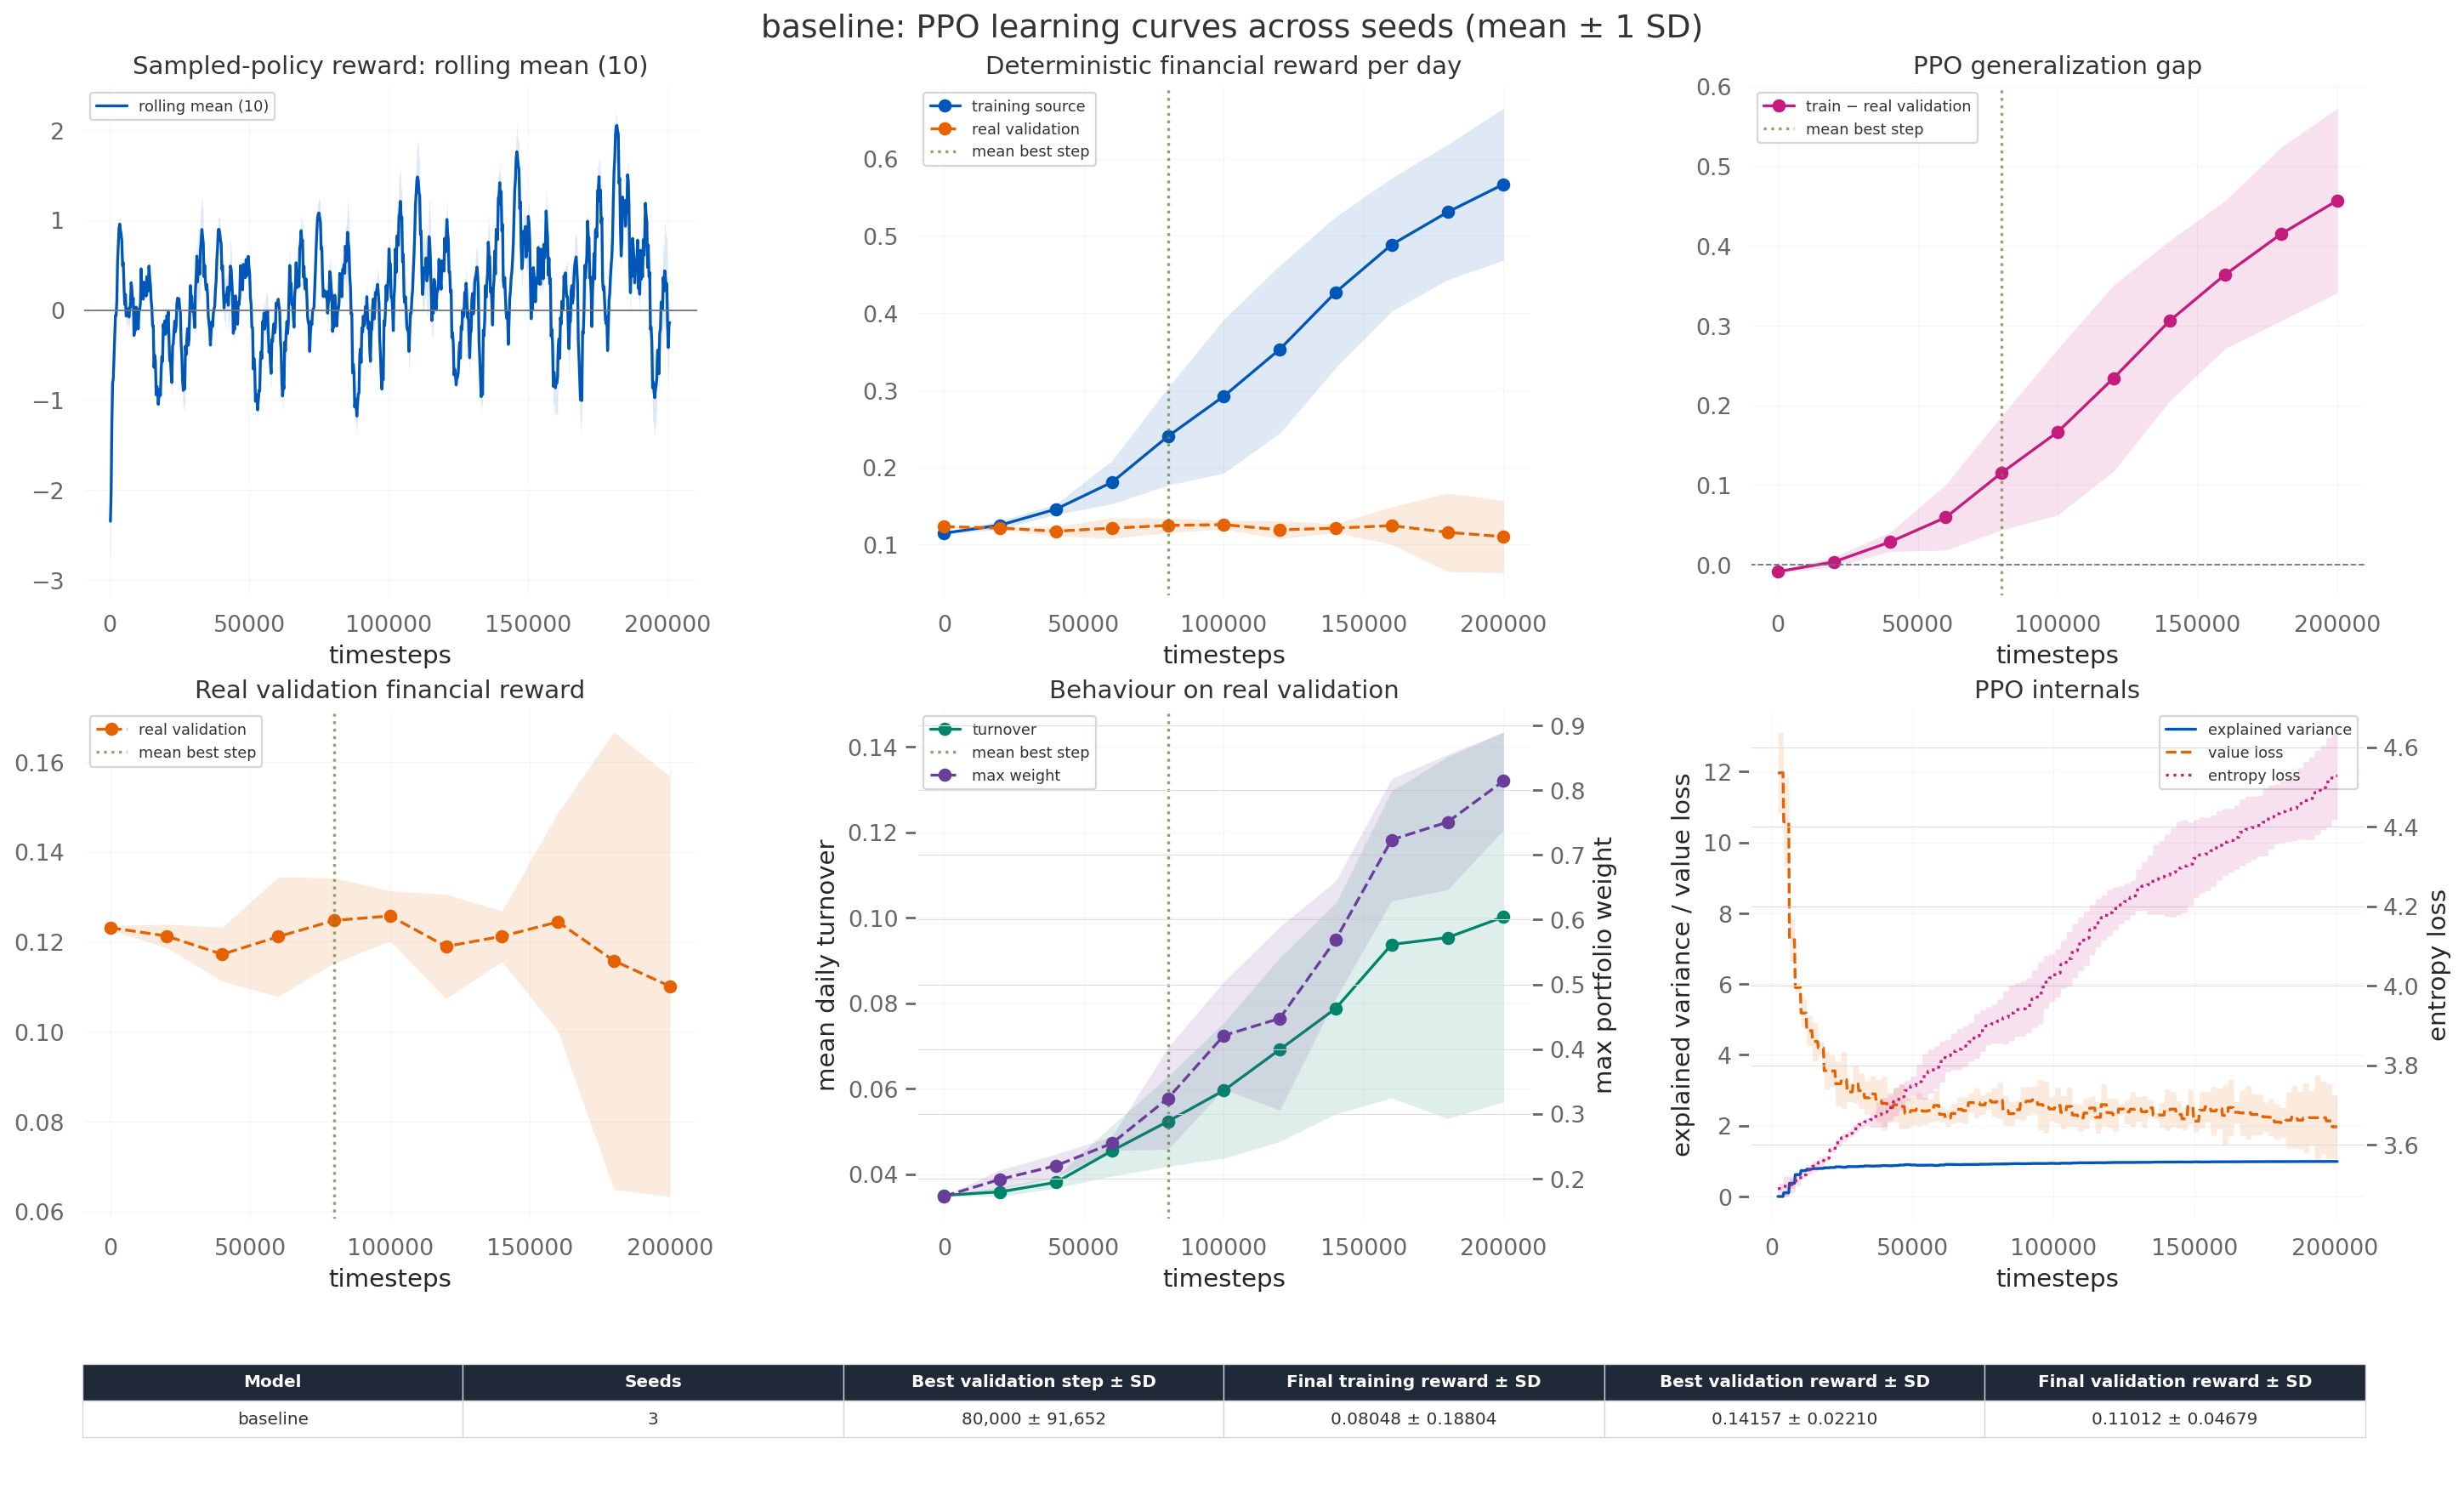

In [8]:
NotebookImage(filename=str(learning_paths[("with_fee", "baseline")]))


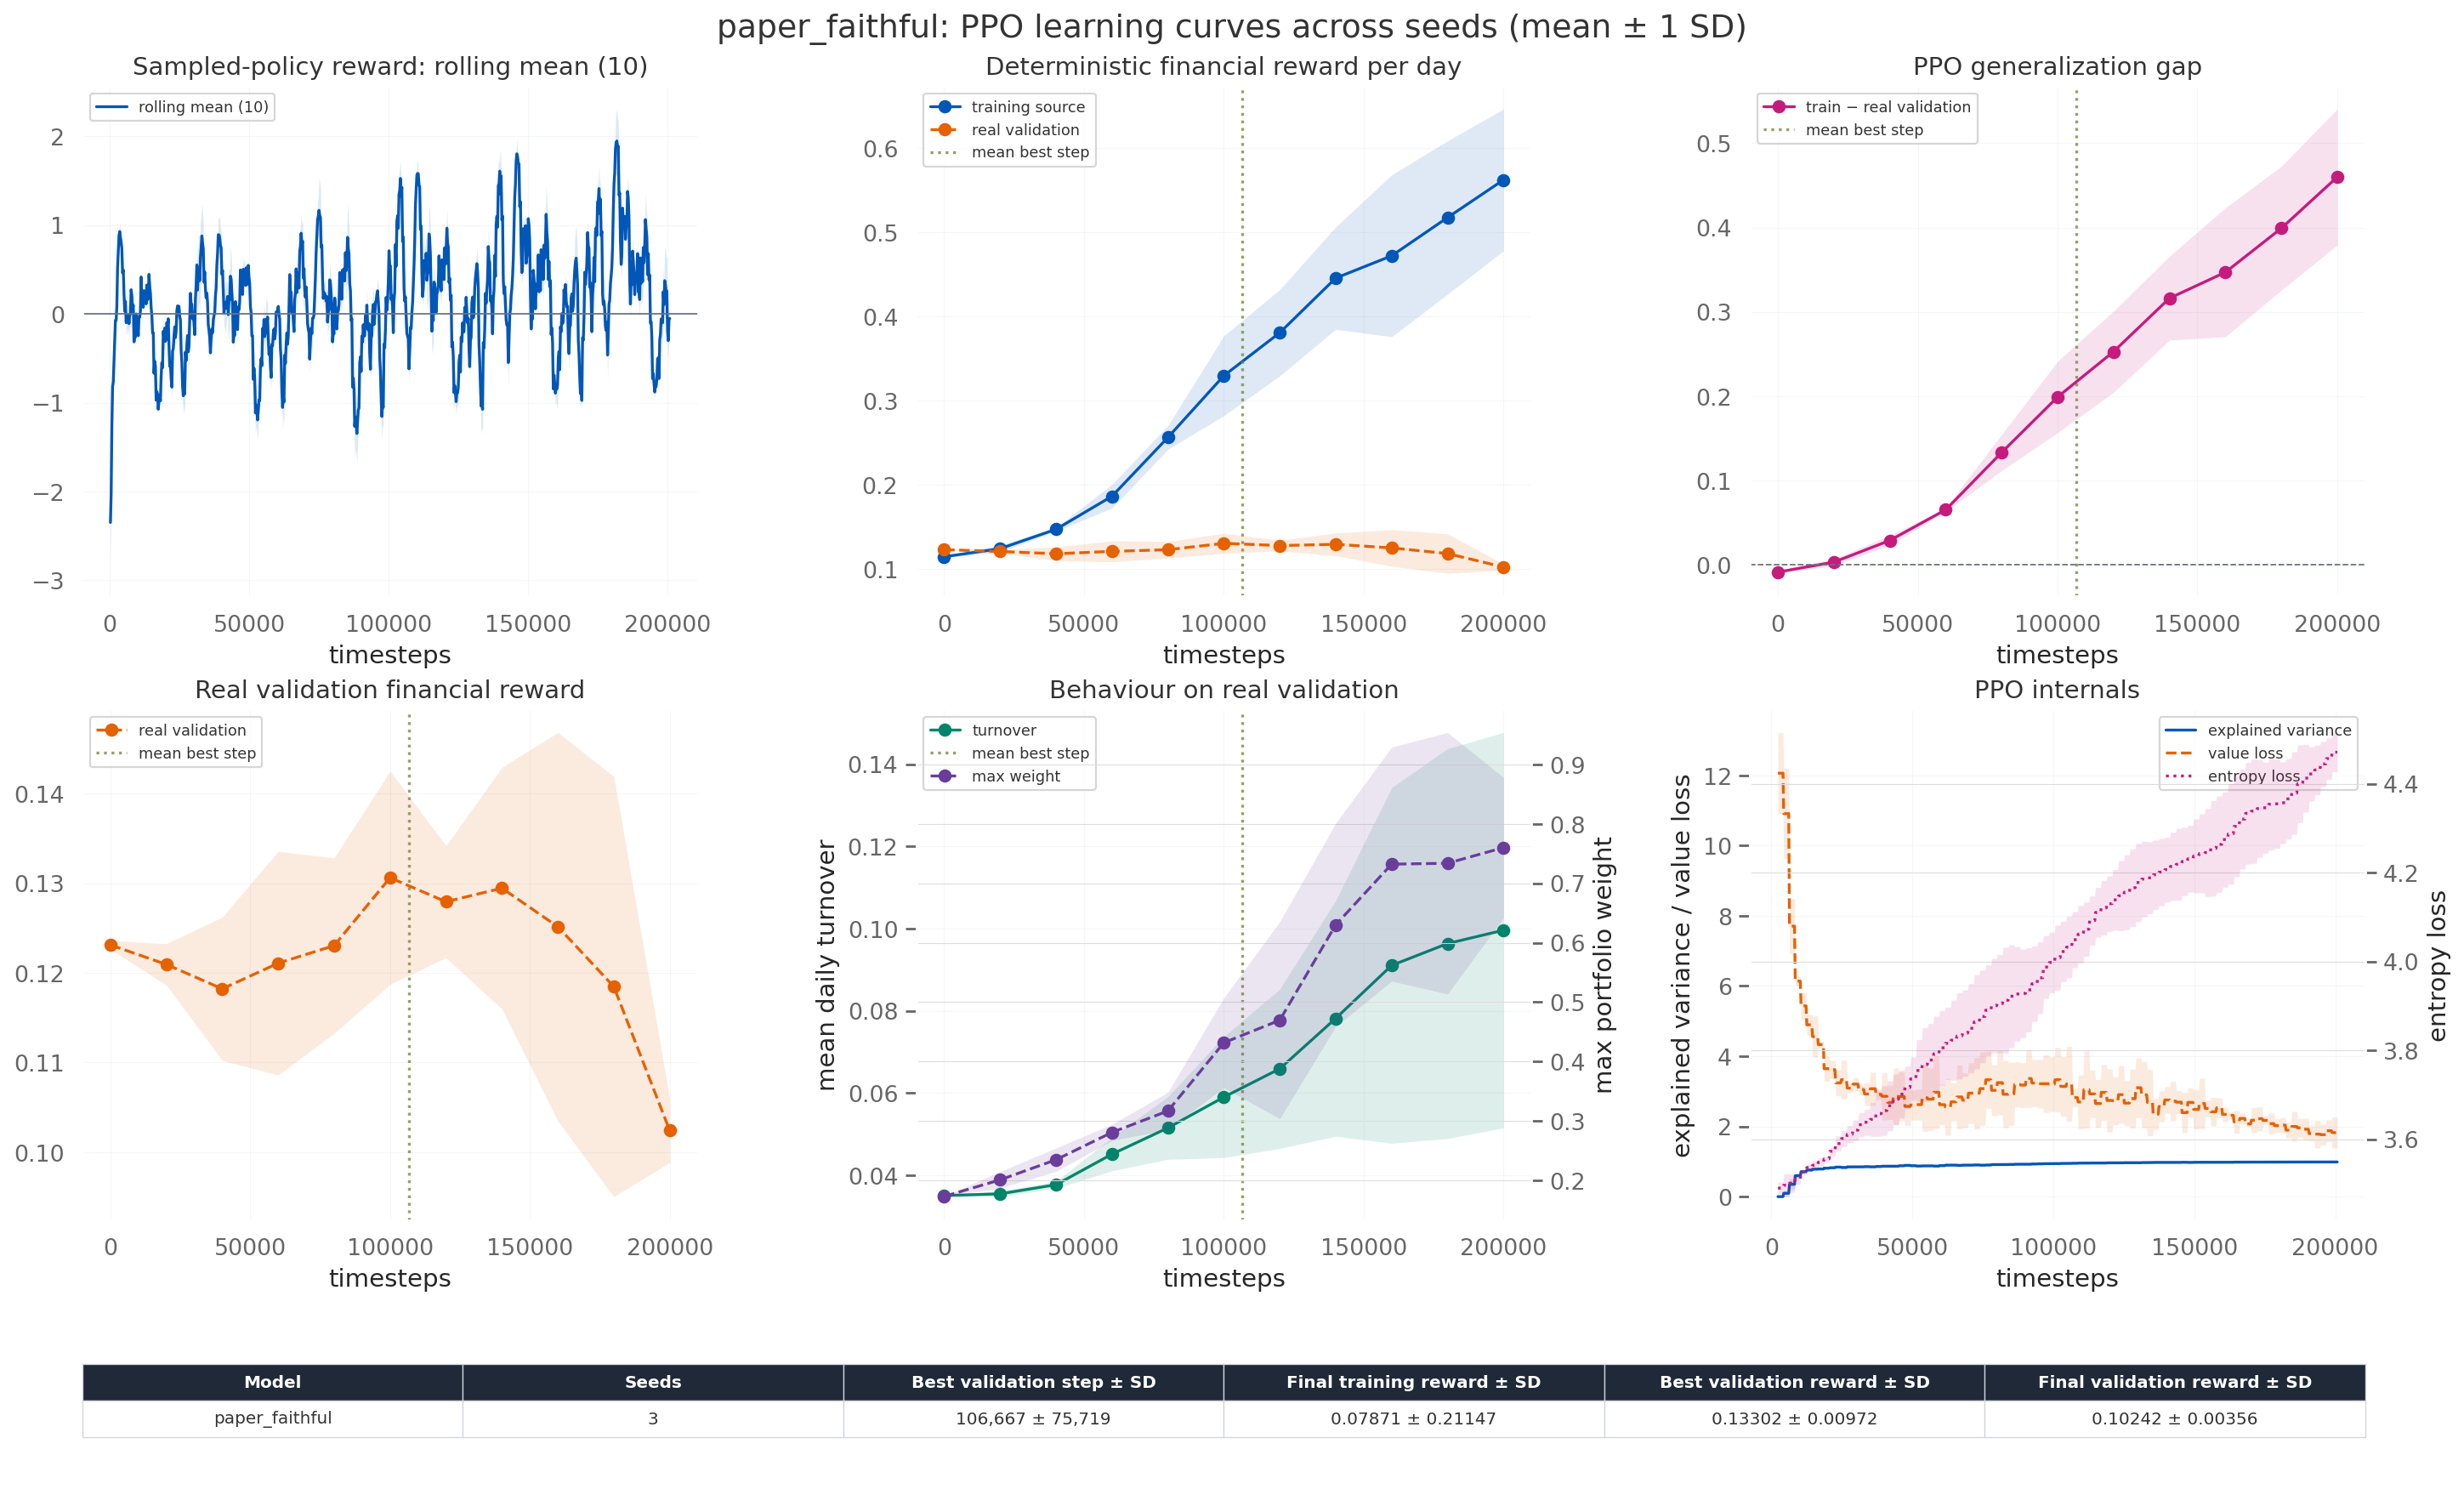

In [9]:
NotebookImage(filename=str(learning_paths[("with_fee", "paper_faithful")]))


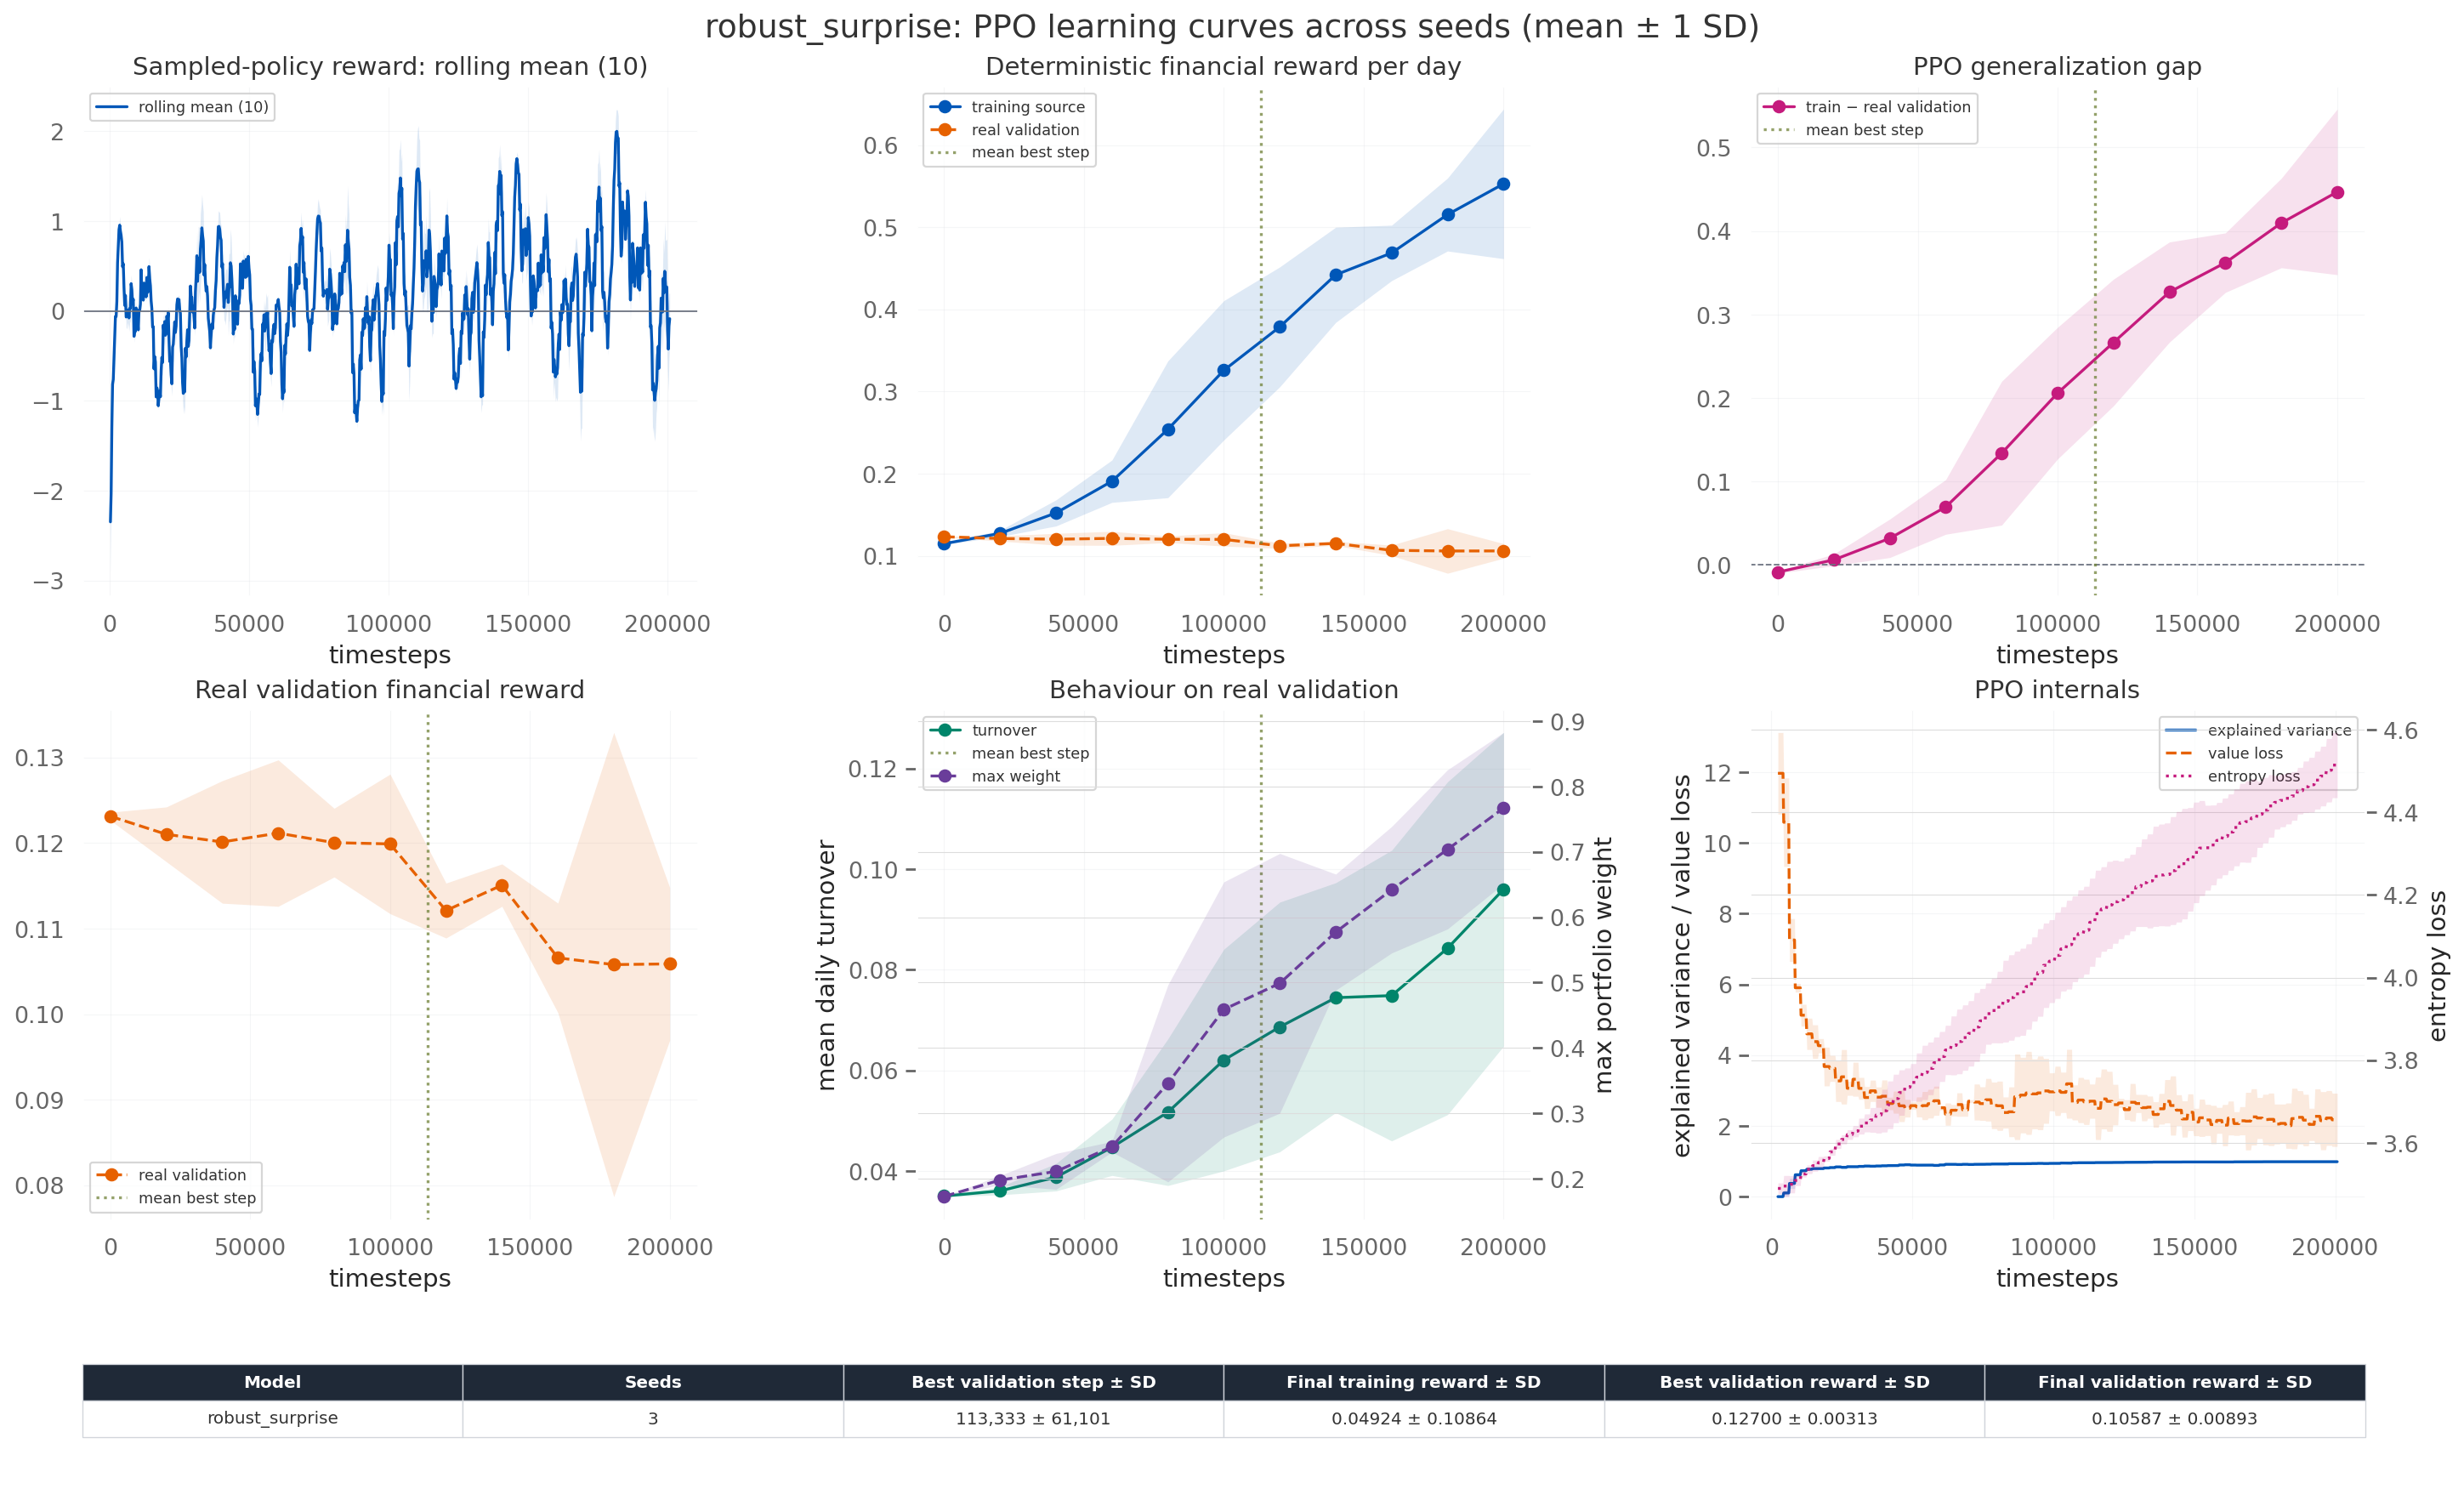

In [10]:
NotebookImage(filename=str(learning_paths[("with_fee", "robust_surprise")]))


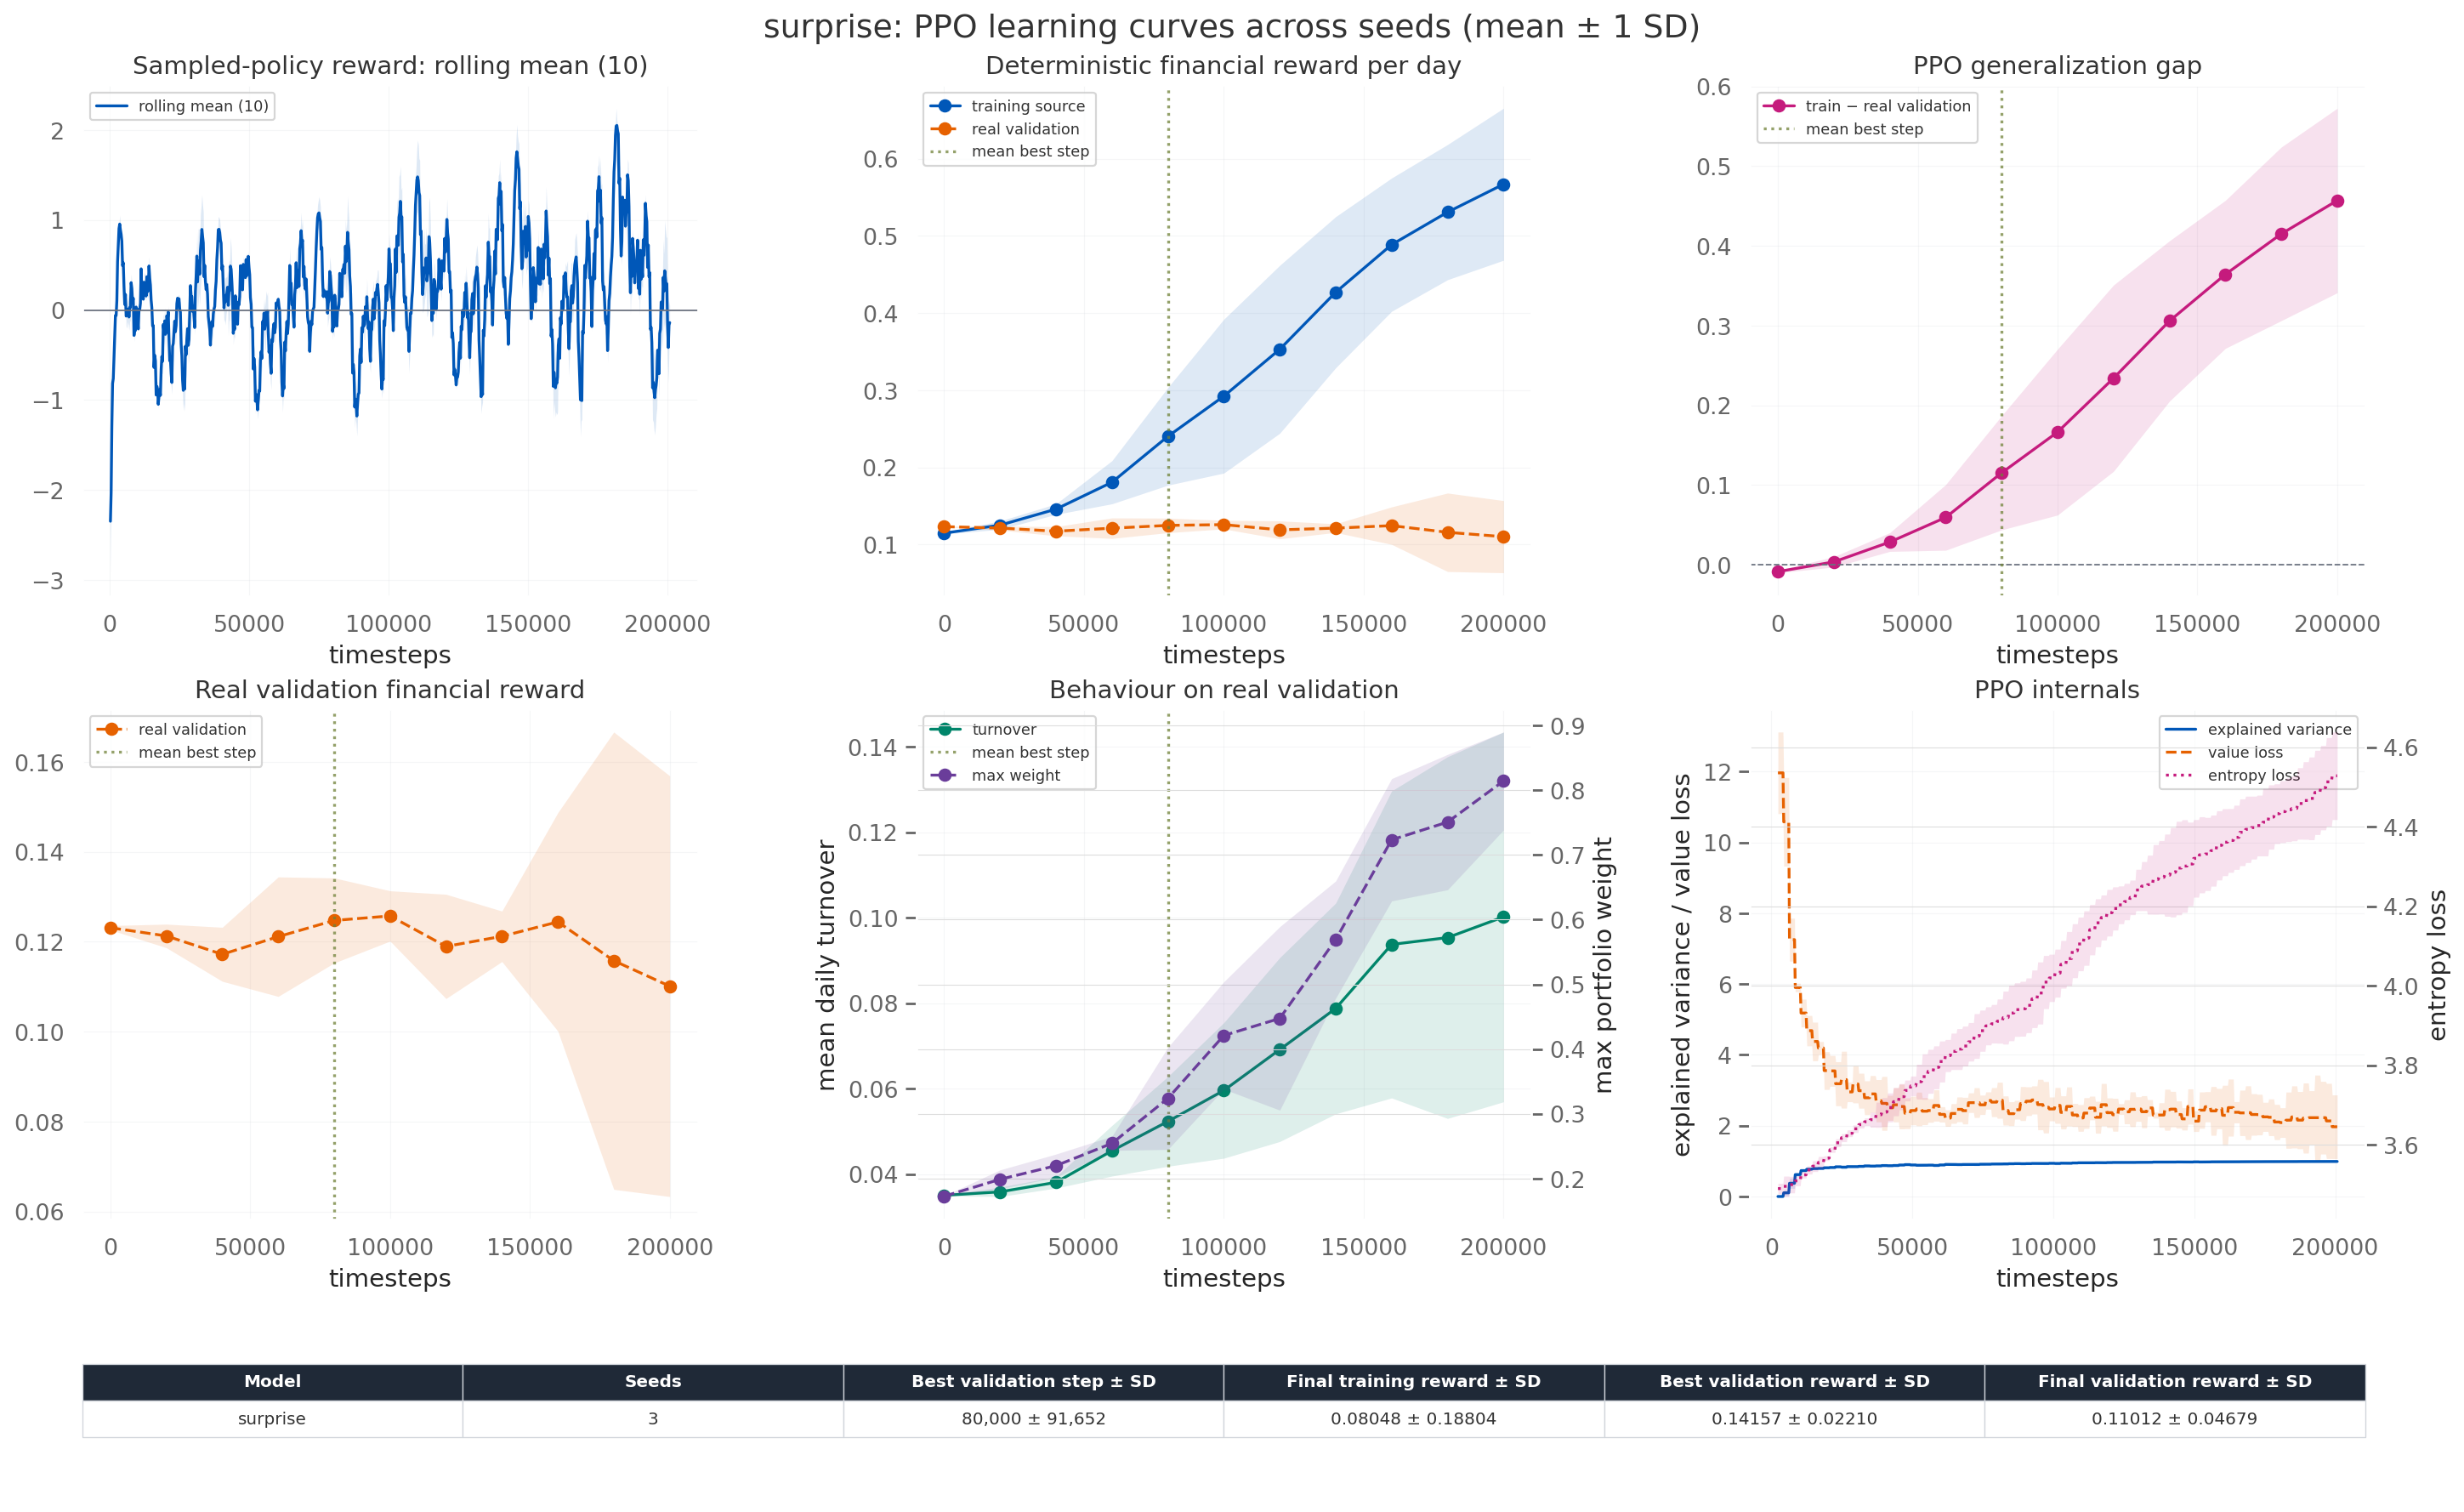

In [11]:
NotebookImage(filename=str(learning_paths[("with_fee", "surprise")]))


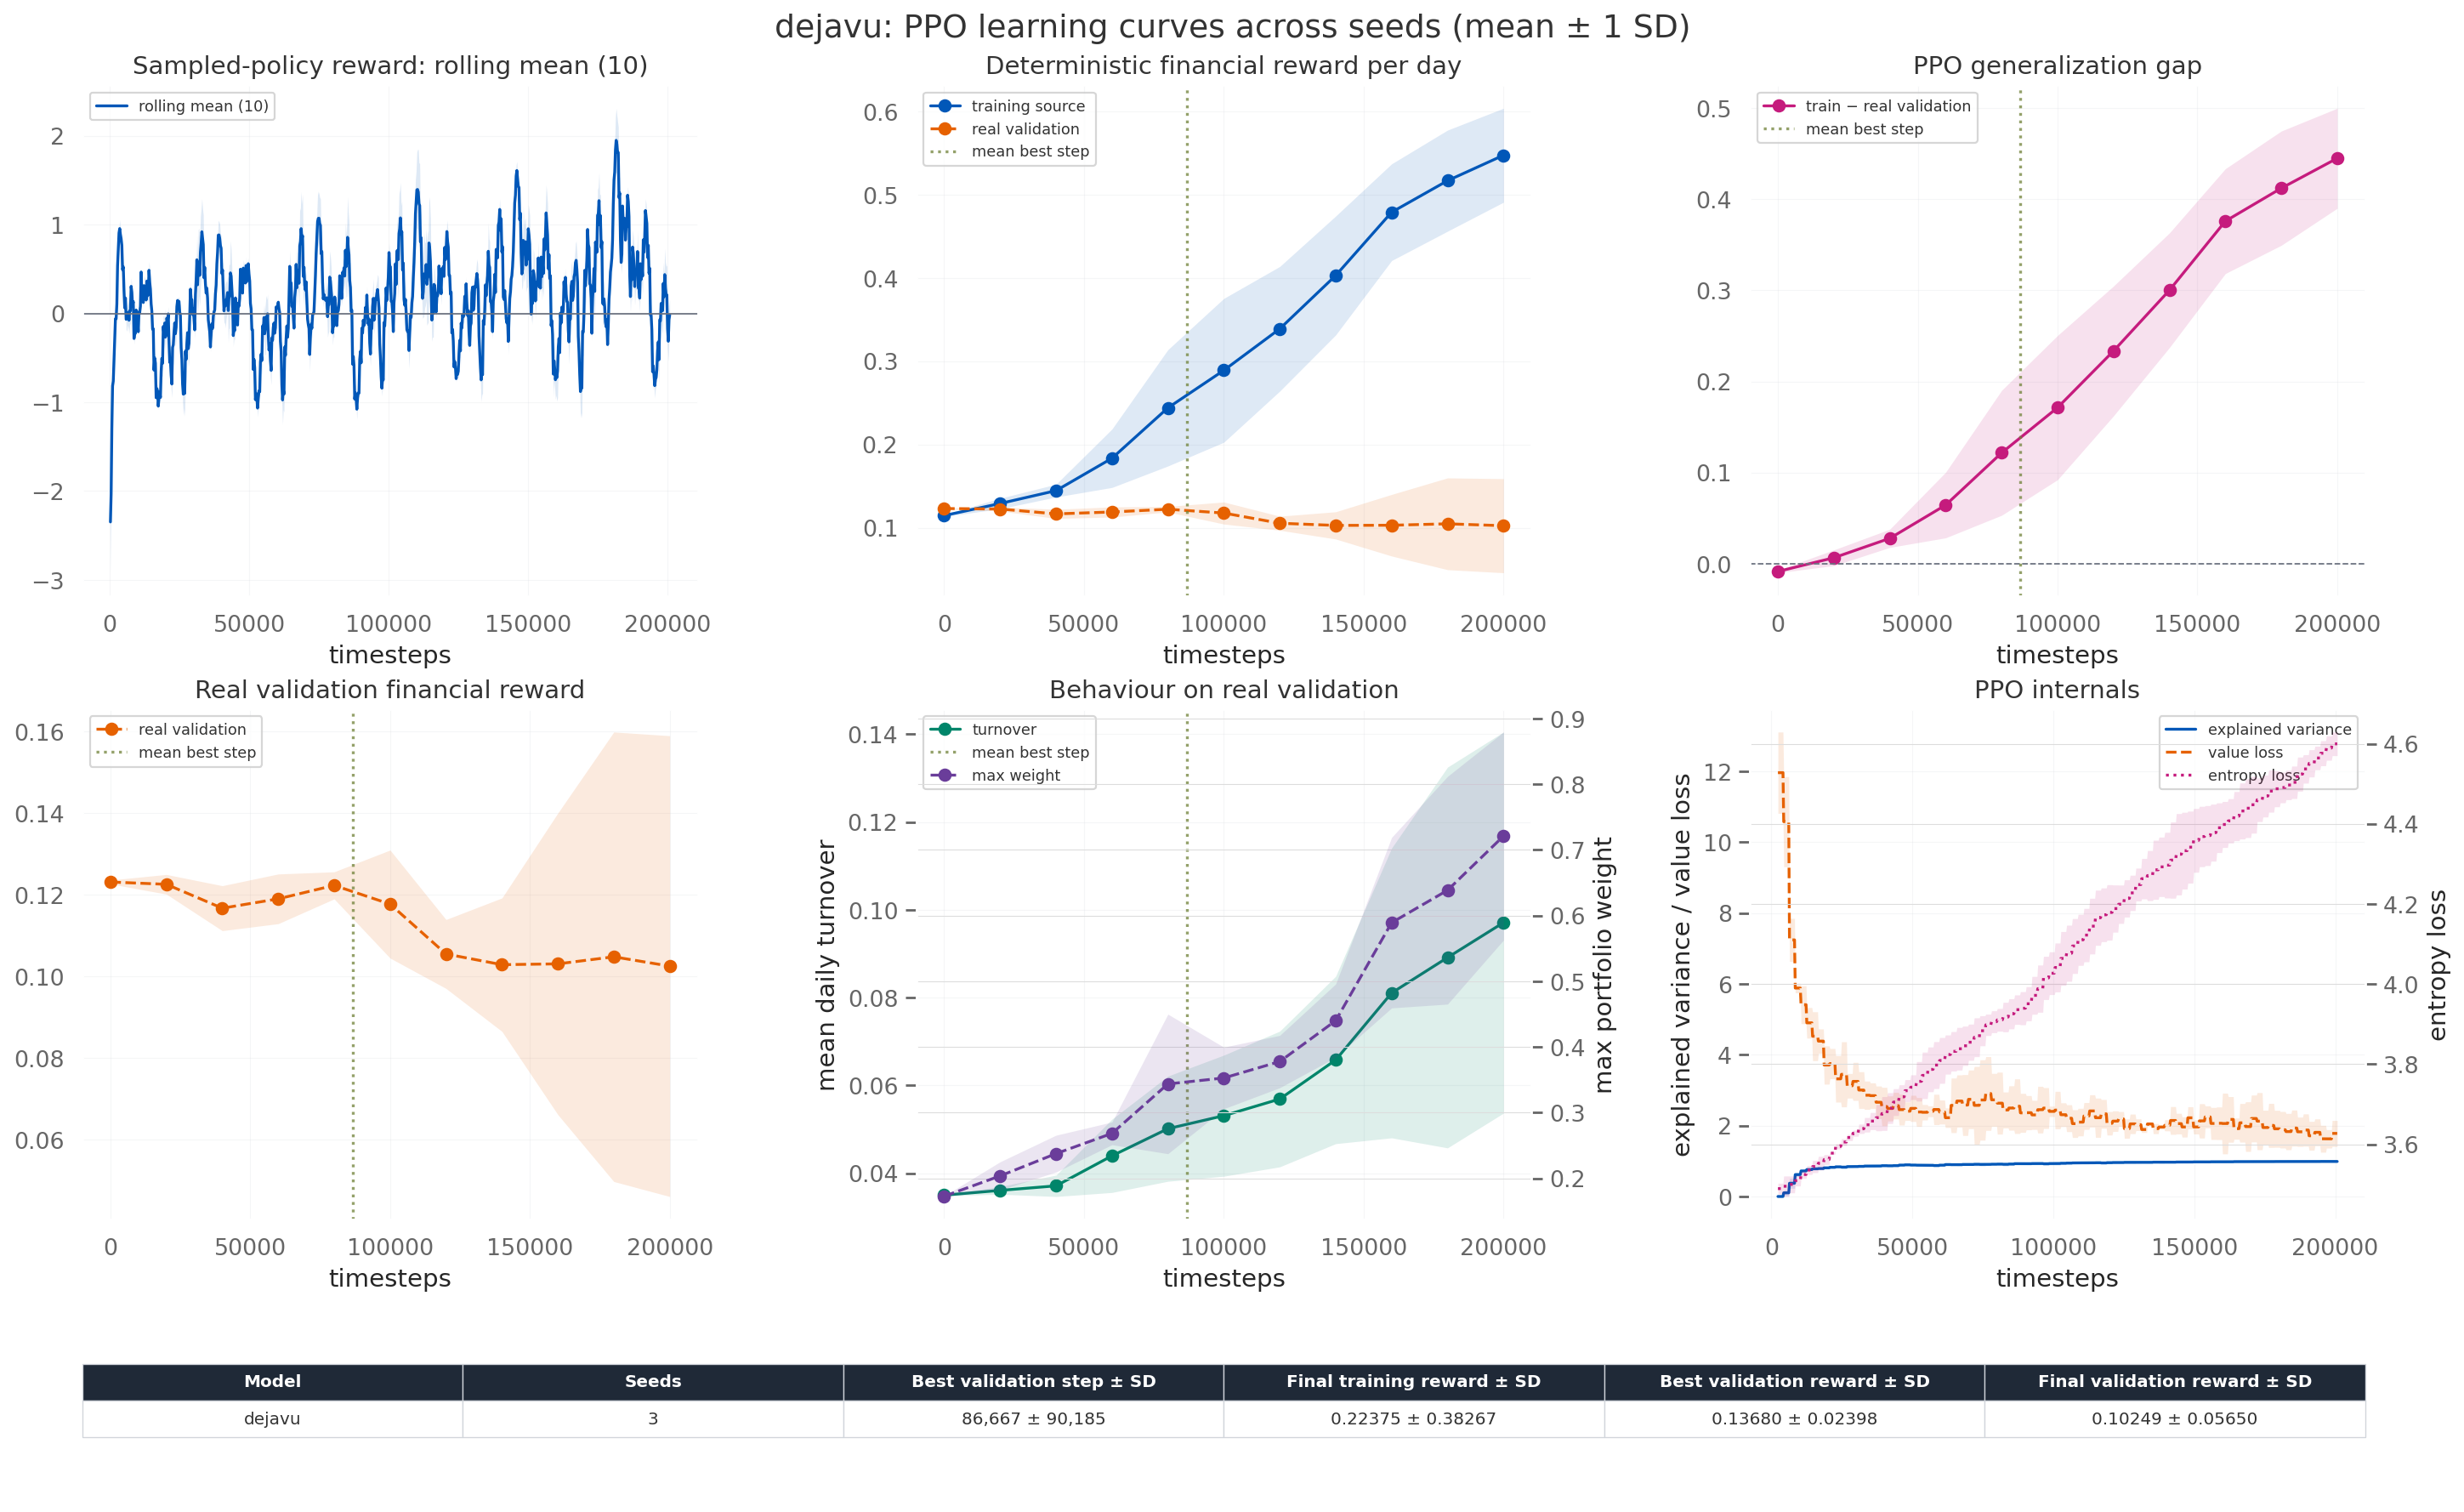

In [12]:
NotebookImage(filename=str(learning_paths[("with_fee", "dejavu")]))


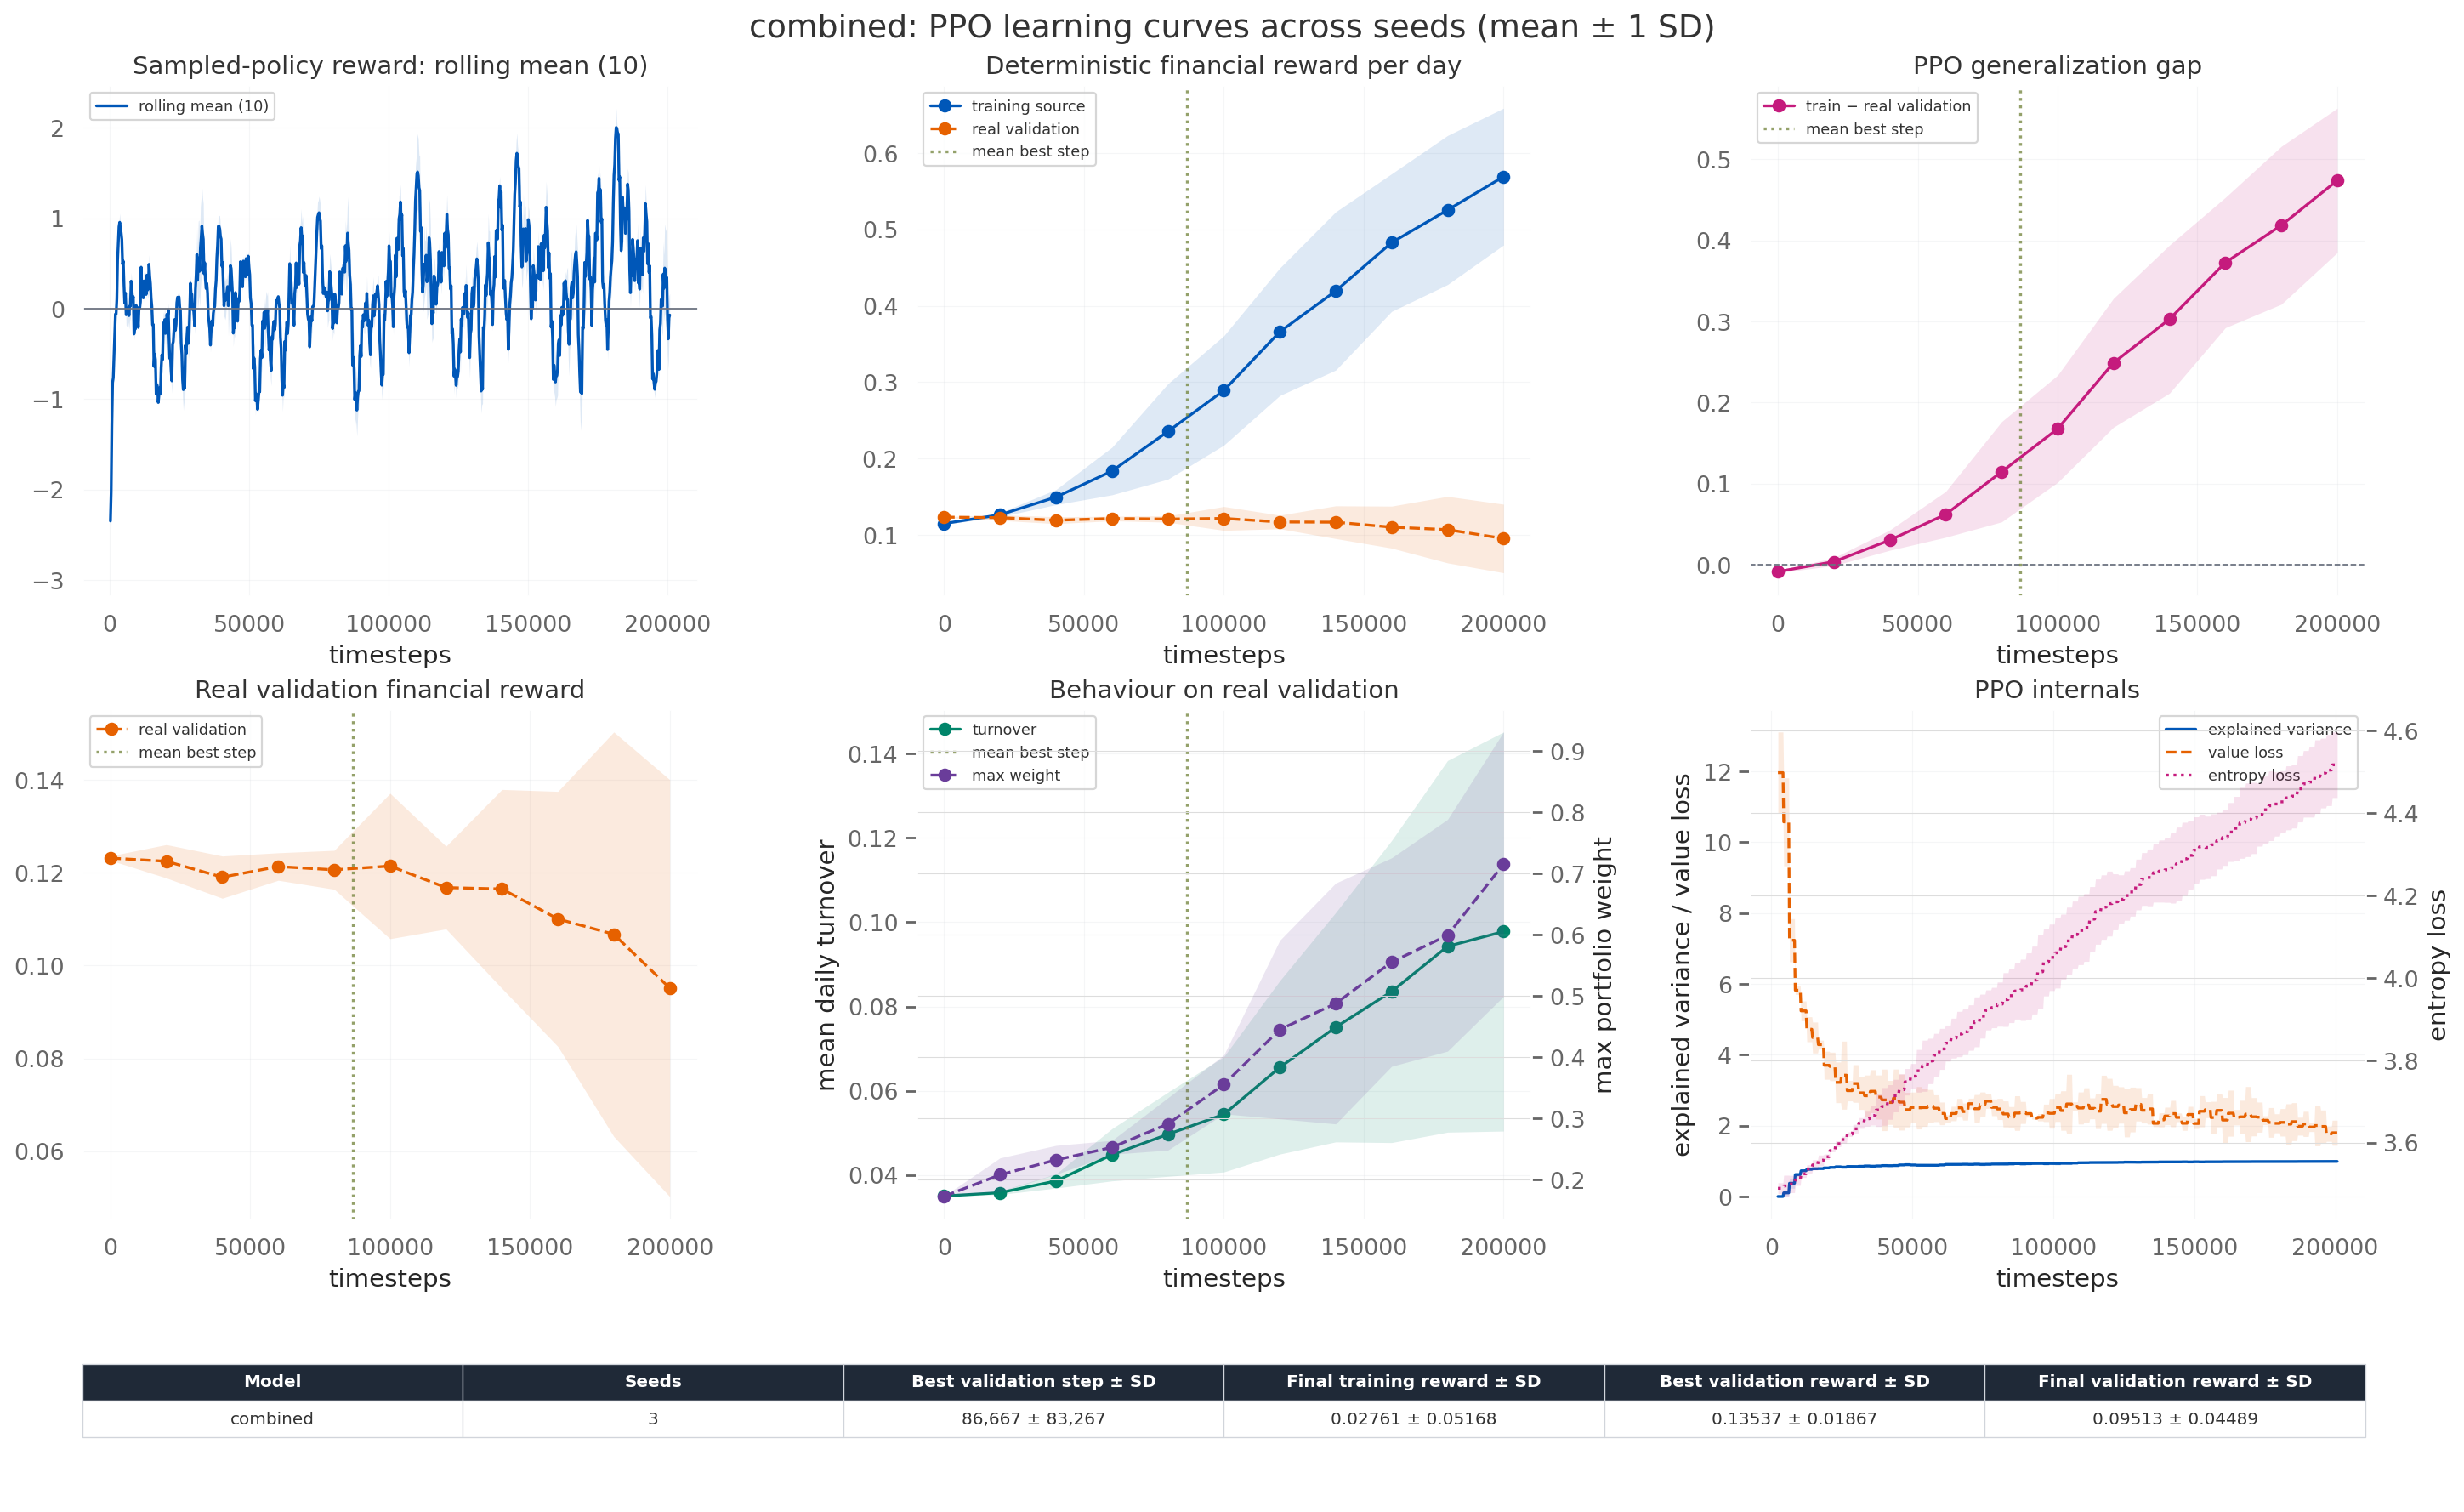

In [13]:
NotebookImage(filename=str(learning_paths[("with_fee", "combined")]))


### Intrinsic-reward diagnostics (additional)

These panels compare the paper-faithful summed NLL, robust centered-z score, legacy
positive-RMS score, Déjà vu, and combined reward. A large or negative paper score is
an experimental result rather than a plotting error; its effective α is dimension
adjusted before reward composition.


In [14]:
intrinsic_log_frames = []
for run in runs:
    if run.variant == "baseline" or run.intrinsic_log.empty:
        continue
    frame = run.intrinsic_log.copy()
    frame["variant"] = run.variant
    frame["commission_name"] = run.commission_name
    frame["seed"] = run.seed
    intrinsic_log_frames.append(frame)
intrinsic_log = pd.concat(intrinsic_log_frames, ignore_index=True)

intrinsic_paths = {}
intrinsic_summaries = []
for commission_name in COMMISSION_CONFIGS:
    commission_log = intrinsic_log.loc[
        intrinsic_log["commission_name"] == commission_name
    ]
    figure, curve_summary, model_summary = plot_intrinsic_diagnostics(
        commission_log
    )
    path = ARTIFACT_ROOT / f"{commission_name}__intrinsic_reward_diagnostics.png"
    figure.savefig(path, dpi=160, bbox_inches="tight")
    plt.close(figure)
    intrinsic_paths[commission_name] = path
    model_summary.insert(1, "commission_name", commission_name)
    intrinsic_summaries.append(model_summary)
pd.concat(intrinsic_summaries, ignore_index=True).to_csv(
    ARTIFACT_ROOT / "intrinsic_reward_summary.csv", index=False
)
intrinsic_paths


{'with_fee': PosixPath('/home/cwei1213/FinRL_Exp/results/ppo_portfolio_intrinsic_reward_ablation/full/with_fee__intrinsic_reward_diagnostics.png')}

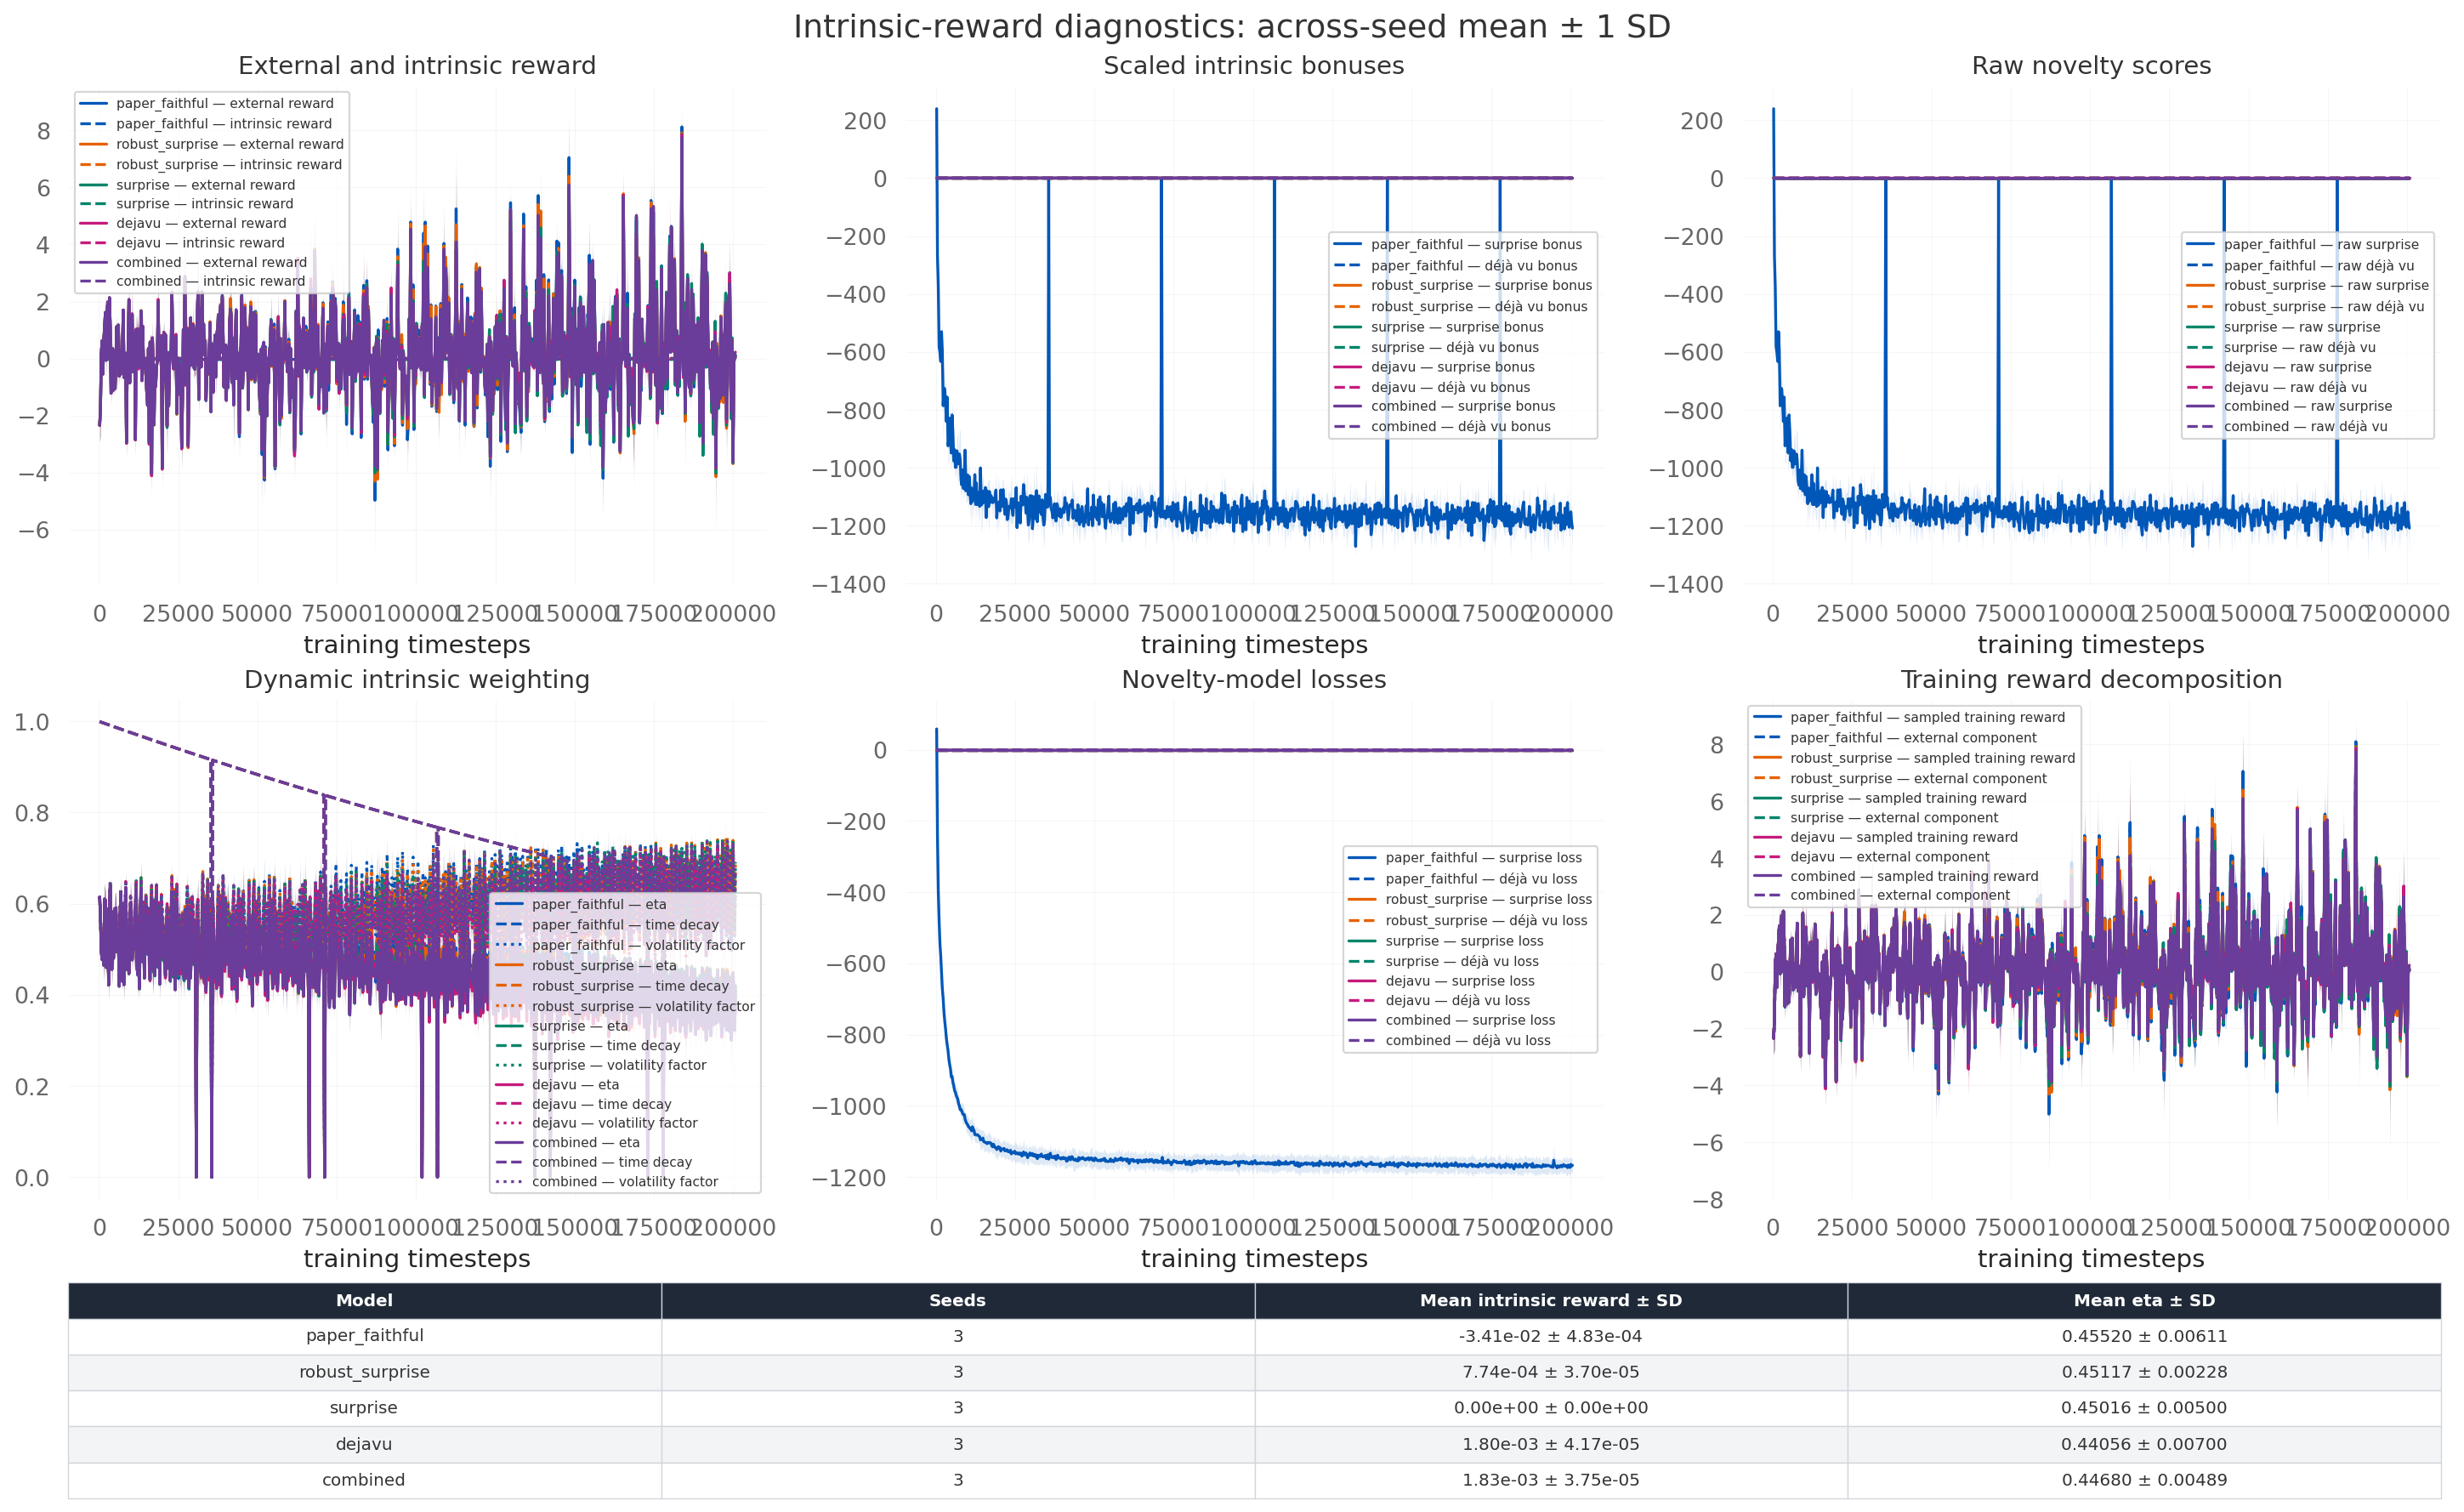

In [15]:
NotebookImage(filename=str(intrinsic_paths["with_fee"]))


## 5. External-reward backtests and uniform benchmark

Every saved PPO checkpoint is evaluated deterministically on train, validation, and
test using the unmodified portfolio environment with a 0.25% fee. The benchmark uses
the same uniform portfolio action as the Real-vs-Synthetic notebook. No intrinsic
reward or novelty-model update occurs here.


In [16]:
(
    ppo_period_summary,
    period_results,
    benchmark_summary,
    benchmark_results,
) = evaluate_portfolio_periods(
    periods,
    runs,
    cwd=PROJECT_ROOT,
    initial_amount=INITIAL_AMOUNT,
    time_window=TIME_WINDOW,
    reward_scaling=REWARD_SCALING,
)
backtest_summary = pd.concat(
    [ppo_period_summary, benchmark_summary], ignore_index=True
)
ppo_period_summary.to_csv(ARTIFACT_ROOT / "ppo_period_metrics.csv", index=False)
benchmark_summary.to_csv(ARTIFACT_ROOT / "benchmark_metrics.csv", index=False)
backtest_summary.to_csv(ARTIFACT_ROOT / "backtest_results.csv", index=False)
backtest_summary


,period,commission_name,commission,variant,seed,best_timestep,final_value,cumulative_return,cagr,sharpe,annualized_volatility,max_drawdown,turnover,reward_per_day
0,train,with_fee,0.0025,baseline,0,180000.0,218738.984375,1.187390,3.175753,4.577910,0.324317,-0.125620,0.120566,0.567180
1,train,with_fee,0.0025,paper_faithful,0,160000.0,204020.093750,1.040201,2.676967,3.878805,0.352195,-0.139123,0.097452,0.516702
2,train,with_fee,0.0025,robust_surprise,0,180000.0,211875.687500,1.118757,2.939603,4.385522,0.325259,-0.120730,0.106940,0.544079
3,train,with_fee,0.0025,surprise,0,180000.0,218738.984375,1.187390,3.175753,4.577910,0.324317,-0.125620,0.120566,0.567180
4,train,with_fee,0.0025,dejavu,0,180000.0,218475.328125,1.184753,3.166566,4.566208,0.324690,-0.118827,0.118078,0.566306
5,train,with_fee,0.0025,combined,0,180000.0,215984.593750,1.159846,3.080234,4.650239,0.313539,-0.113048,0.116598,0.557998
6,train,with_fee,0.0025,baseline,1,0.0,116981.390625,0.169814,0.331641,1.560930,0.195826,-0.146432,0.022516,0.113656
7,train,with_fee,0.0025,paper_faithful,1,140000.0,197445.187500,0.974452,2.463467,4.186952,0.308543,-0.135105,0.096025,0.492964
8,train,with_fee,0.0025,robust_surprise,1,100000.0,177910.796875,0.779108,1.863460,3.476430,0.317478,-0.151062,0.077139,0.417473
9,train,with_fee,0.0025,surprise,1,0.0,116981.390625,0.169814,0.331641,1.560930,0.195826,-0.146432,0.022516,0.113656


## 6. Backtest Sharpe and test metrics

The Sharpe plot retains every seed and marks the seed nearest each variant's median
test Sharpe. The metric plot shows all-seed mean ± SD and the deterministic uniform
benchmark, all under the 0.25% fee condition.


In [17]:
sharpe_paths = {}
metric_paths = {}
test_model_summaries = []
for commission_name in COMMISSION_CONFIGS:
    test_summary = ppo_period_summary.loc[
        (ppo_period_summary["period"] == "test")
        & (ppo_period_summary["commission_name"] == commission_name)
    ].reset_index(drop=True)
    test_benchmark = benchmark_summary.loc[
        (benchmark_summary["period"] == "test")
        & (benchmark_summary["commission_name"] == commission_name)
    ].iloc[0]

    sharpe_figure, representatives = plot_sharpe_seed_selection(test_summary)
    sharpe_path = ARTIFACT_ROOT / f"{commission_name}__median_sharpe_seed_selection.png"
    sharpe_figure.savefig(sharpe_path, dpi=160, bbox_inches="tight")
    plt.close(sharpe_figure)
    representatives.to_csv(
        ARTIFACT_ROOT / f"{commission_name}__median_sharpe_representatives.csv",
        index=False,
    )
    sharpe_paths[commission_name] = sharpe_path

    metrics_figure, model_summary = plot_test_metric_comparison(
        test_summary, test_benchmark
    )
    metrics_path = ARTIFACT_ROOT / f"{commission_name}__test_metrics_vs_benchmark.png"
    metrics_figure.savefig(metrics_path, dpi=160, bbox_inches="tight")
    plt.close(metrics_figure)
    model_summary.insert(1, "commission_name", commission_name)
    test_model_summaries.append(model_summary)
    metric_paths[commission_name] = metrics_path

test_model_summary = pd.concat(test_model_summaries, ignore_index=True)
test_model_summary.to_csv(
    ARTIFACT_ROOT / "test_metrics_aggregated.csv", index=False
)


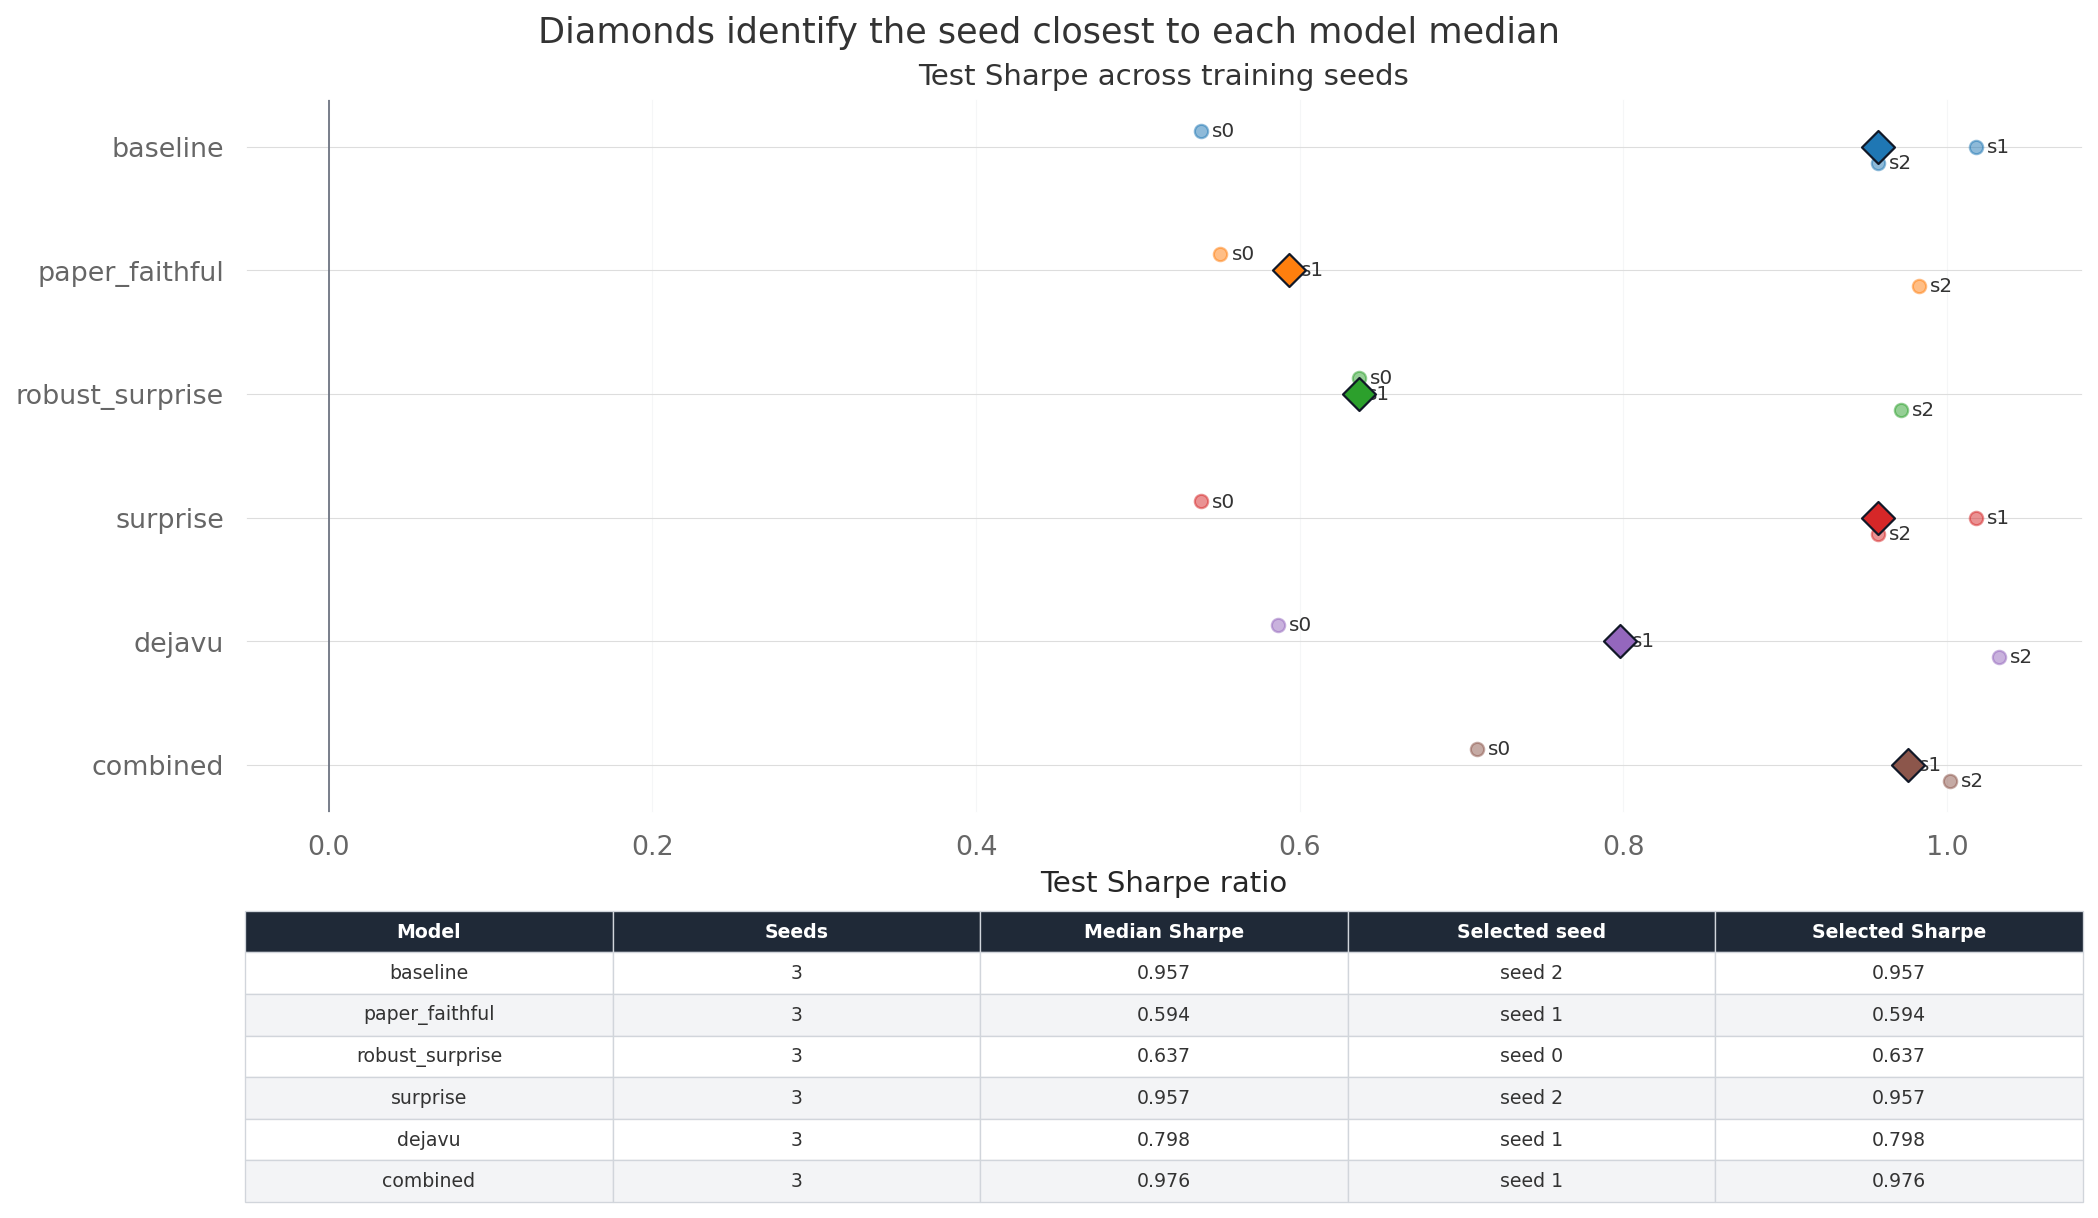

In [18]:
NotebookImage(filename=str(sharpe_paths["with_fee"]))


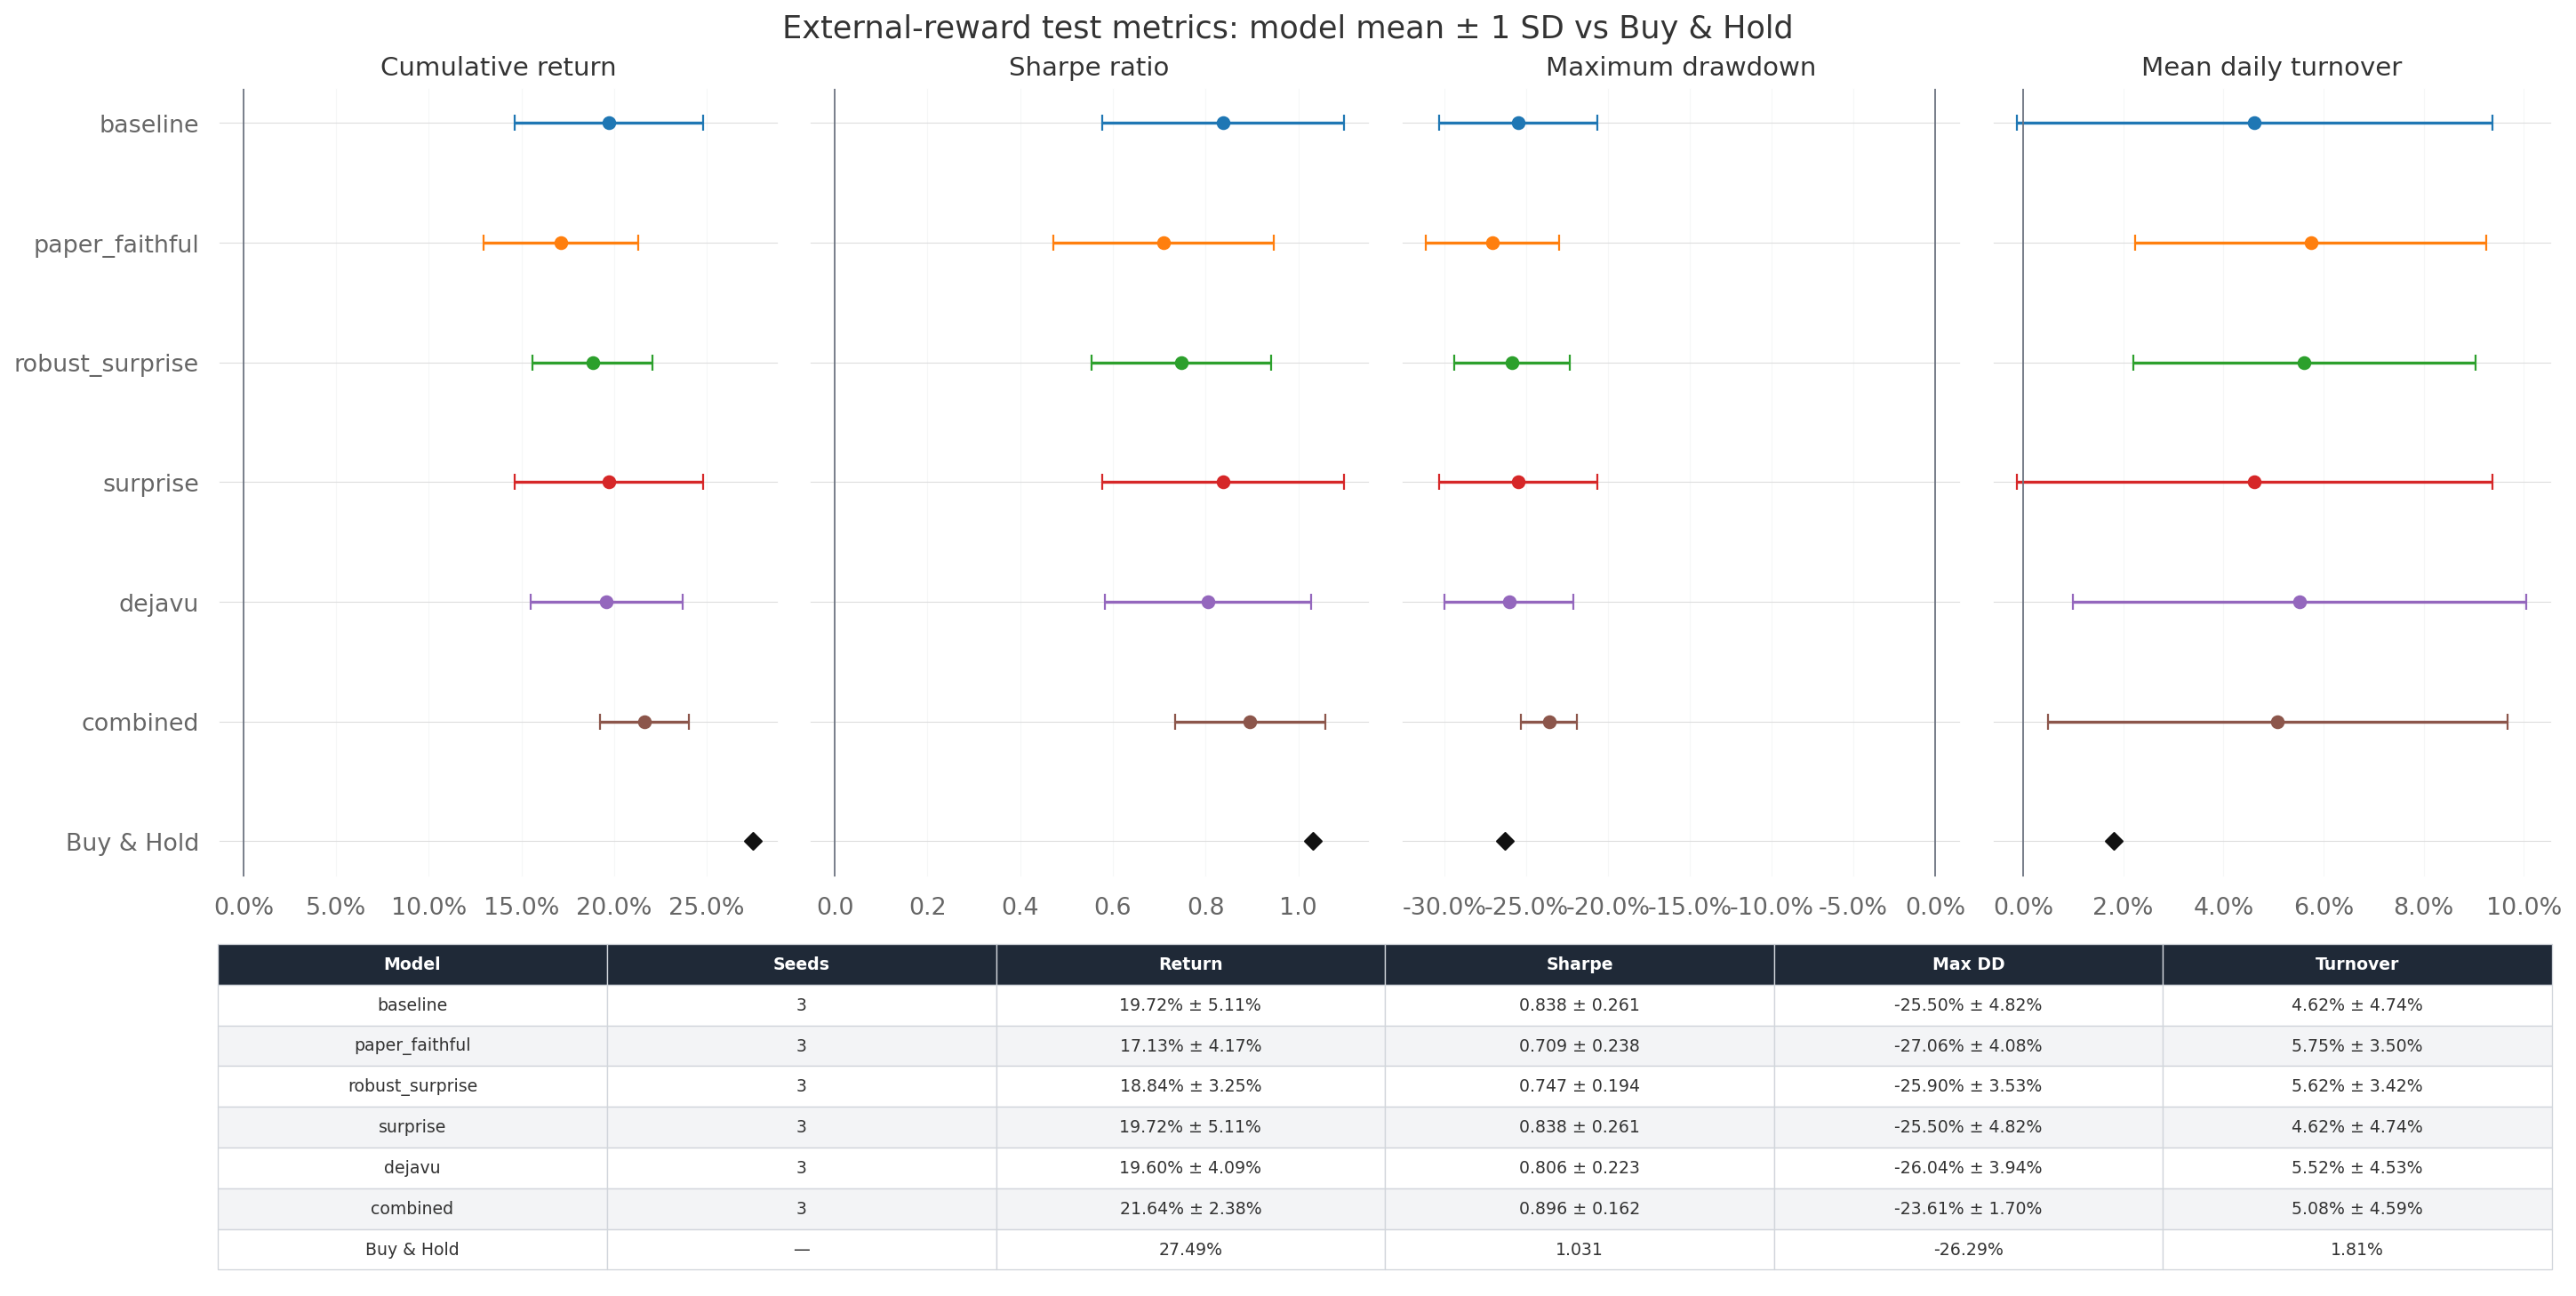

In [19]:
NotebookImage(filename=str(metric_paths["with_fee"]))


## 7. Train, validation, and test equity curves

All plots use Growth of $1 under `with_fee=0.0025`. Reward variants are aggregated
across seeds as mean ± SD; the uniform benchmark is the dashed black line. Tables
report the exact ranking for the corresponding period.


In [20]:
equity_paths = {}
period_titles = {
    "train": f"Real train [{TRAIN_START}, {TRAIN_END})",
    "validation": f"Real validation [{VALIDATION_START}, {VALIDATION_END})",
    "test": f"Real test [{TEST_START}, {TEST_END})",
}
for commission_name in COMMISSION_CONFIGS:
    for period in ("train", "validation", "test"):
        figure, equity, ranking = plot_period_equity_comparison(
            period,
            period_results[commission_name][period],
            benchmark_results[commission_name][period],
            f"{period_titles[period]} — {commission_name}",
        )
        path = ARTIFACT_ROOT / (
            f"{commission_name}__ppo_vs_benchmark_{period}_equity_curves.png"
        )
        figure.savefig(path, dpi=160, bbox_inches="tight")
        plt.close(figure)
        equity.to_csv(
            ARTIFACT_ROOT / f"{commission_name}__{period}_equity_curves.csv",
            index=False,
        )
        ranking.to_csv(
            ARTIFACT_ROOT / f"{commission_name}__{period}_equity_ranking.csv",
            index=False,
        )
        equity_paths[(commission_name, period)] = path
equity_paths


{('with_fee',
  'train'): PosixPath('/home/cwei1213/FinRL_Exp/results/ppo_portfolio_intrinsic_reward_ablation/full/with_fee__ppo_vs_benchmark_train_equity_curves.png'),
 ('with_fee',
  'validation'): PosixPath('/home/cwei1213/FinRL_Exp/results/ppo_portfolio_intrinsic_reward_ablation/full/with_fee__ppo_vs_benchmark_validation_equity_curves.png'),
 ('with_fee',
  'test'): PosixPath('/home/cwei1213/FinRL_Exp/results/ppo_portfolio_intrinsic_reward_ablation/full/with_fee__ppo_vs_benchmark_test_equity_curves.png')}

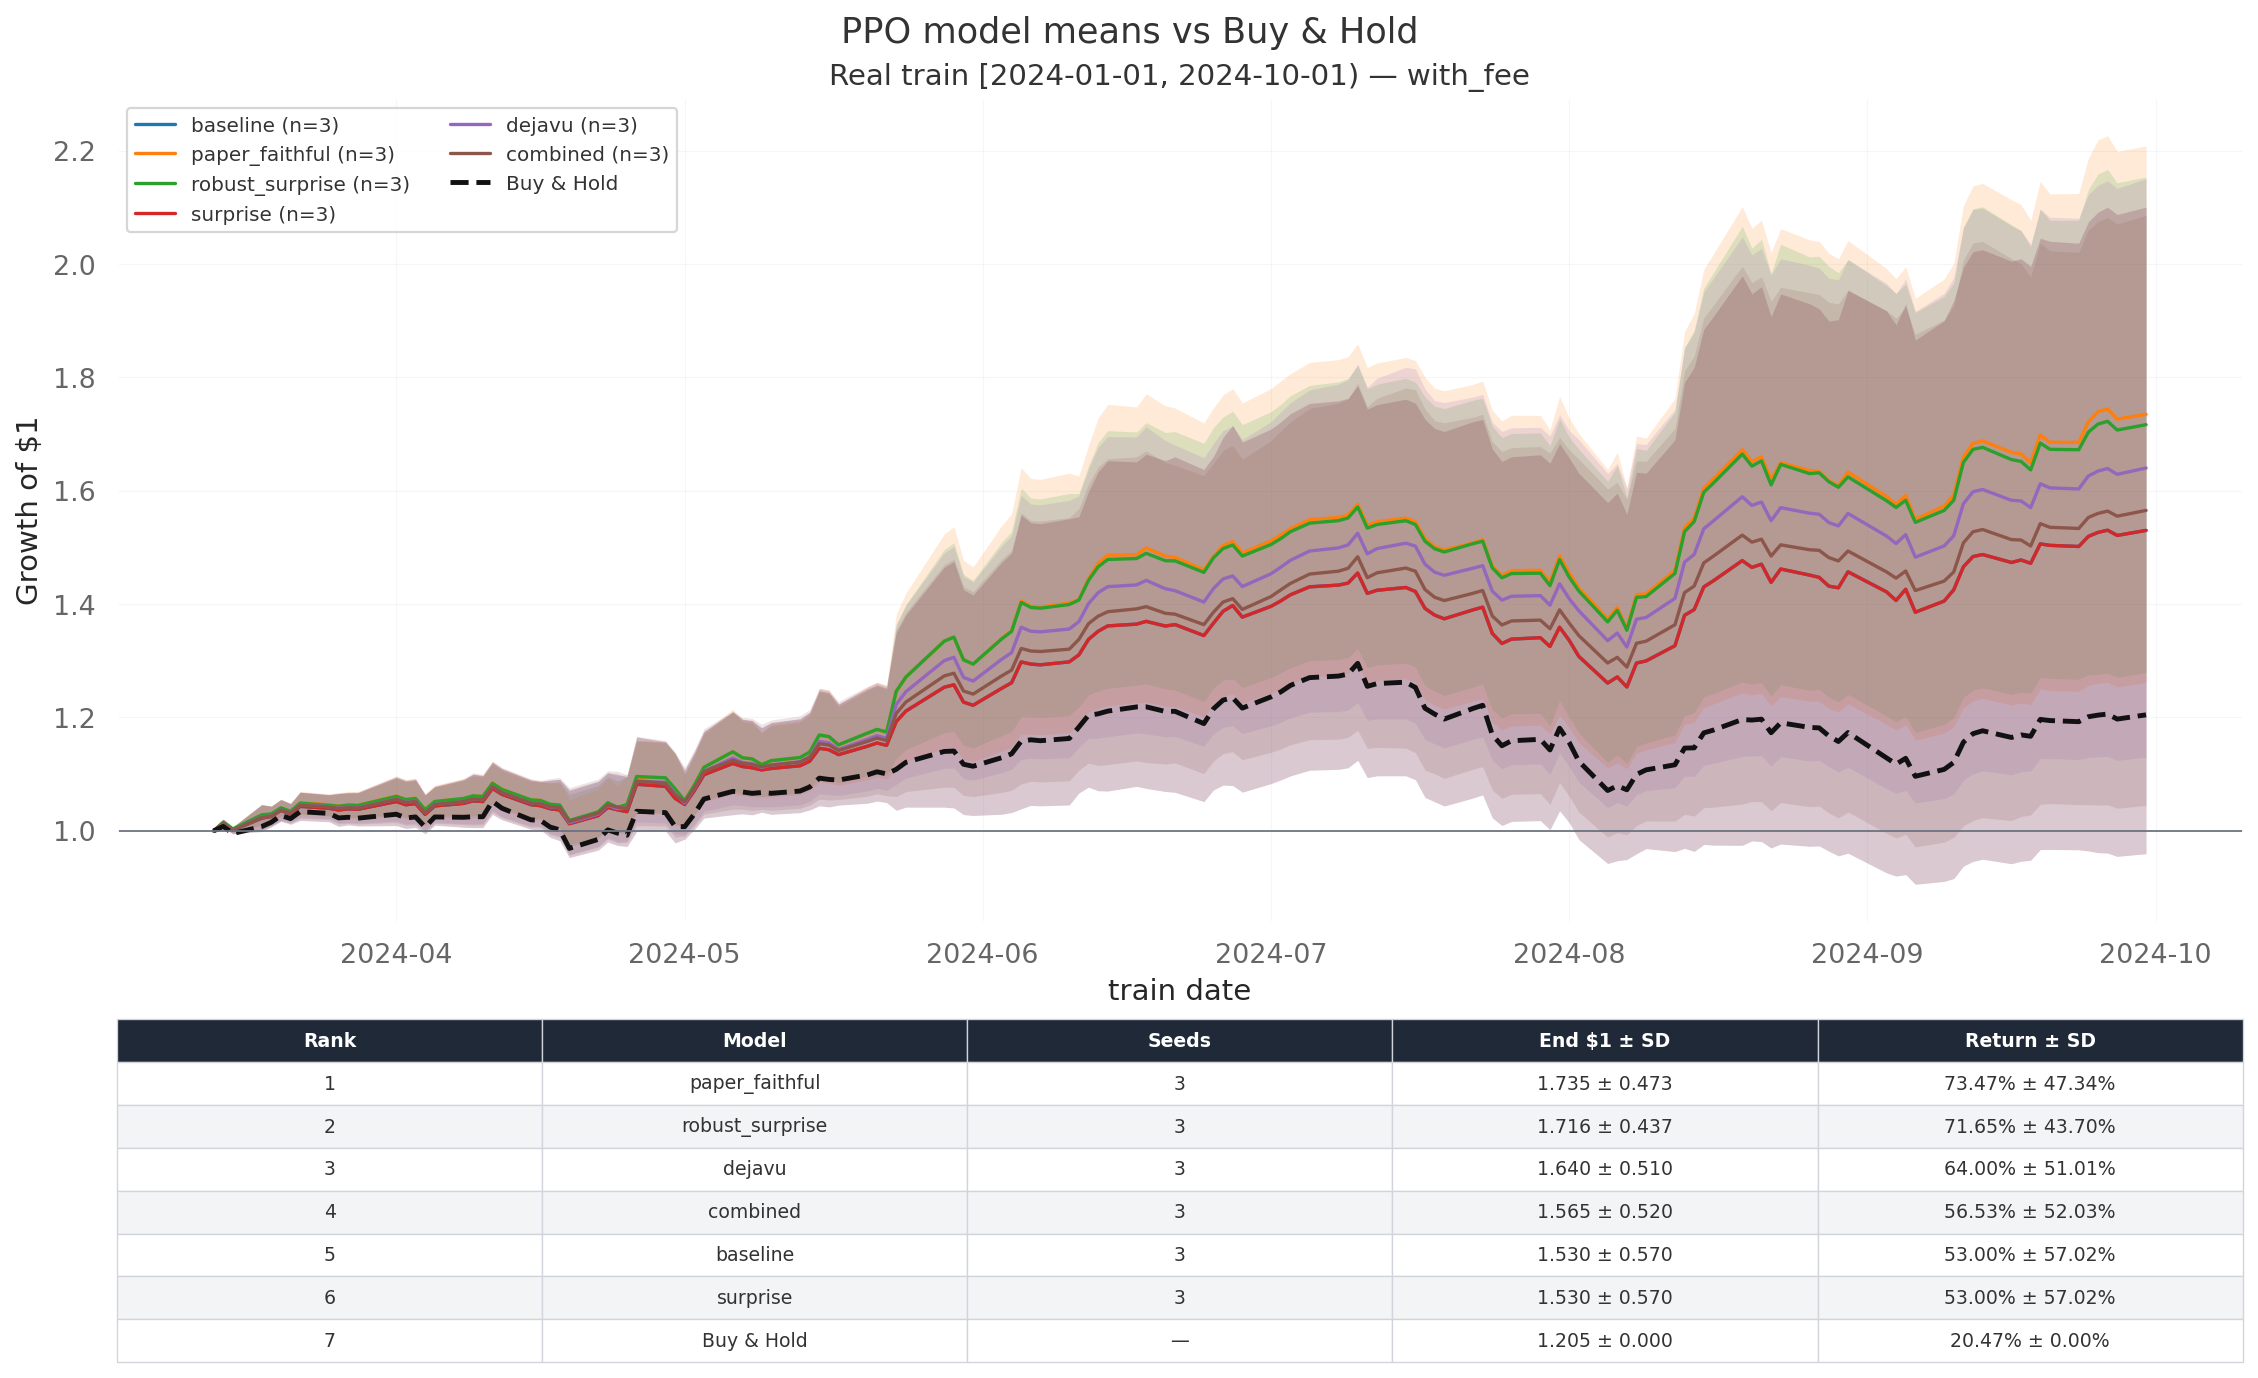

In [21]:
NotebookImage(filename=str(equity_paths[("with_fee", "train")]))


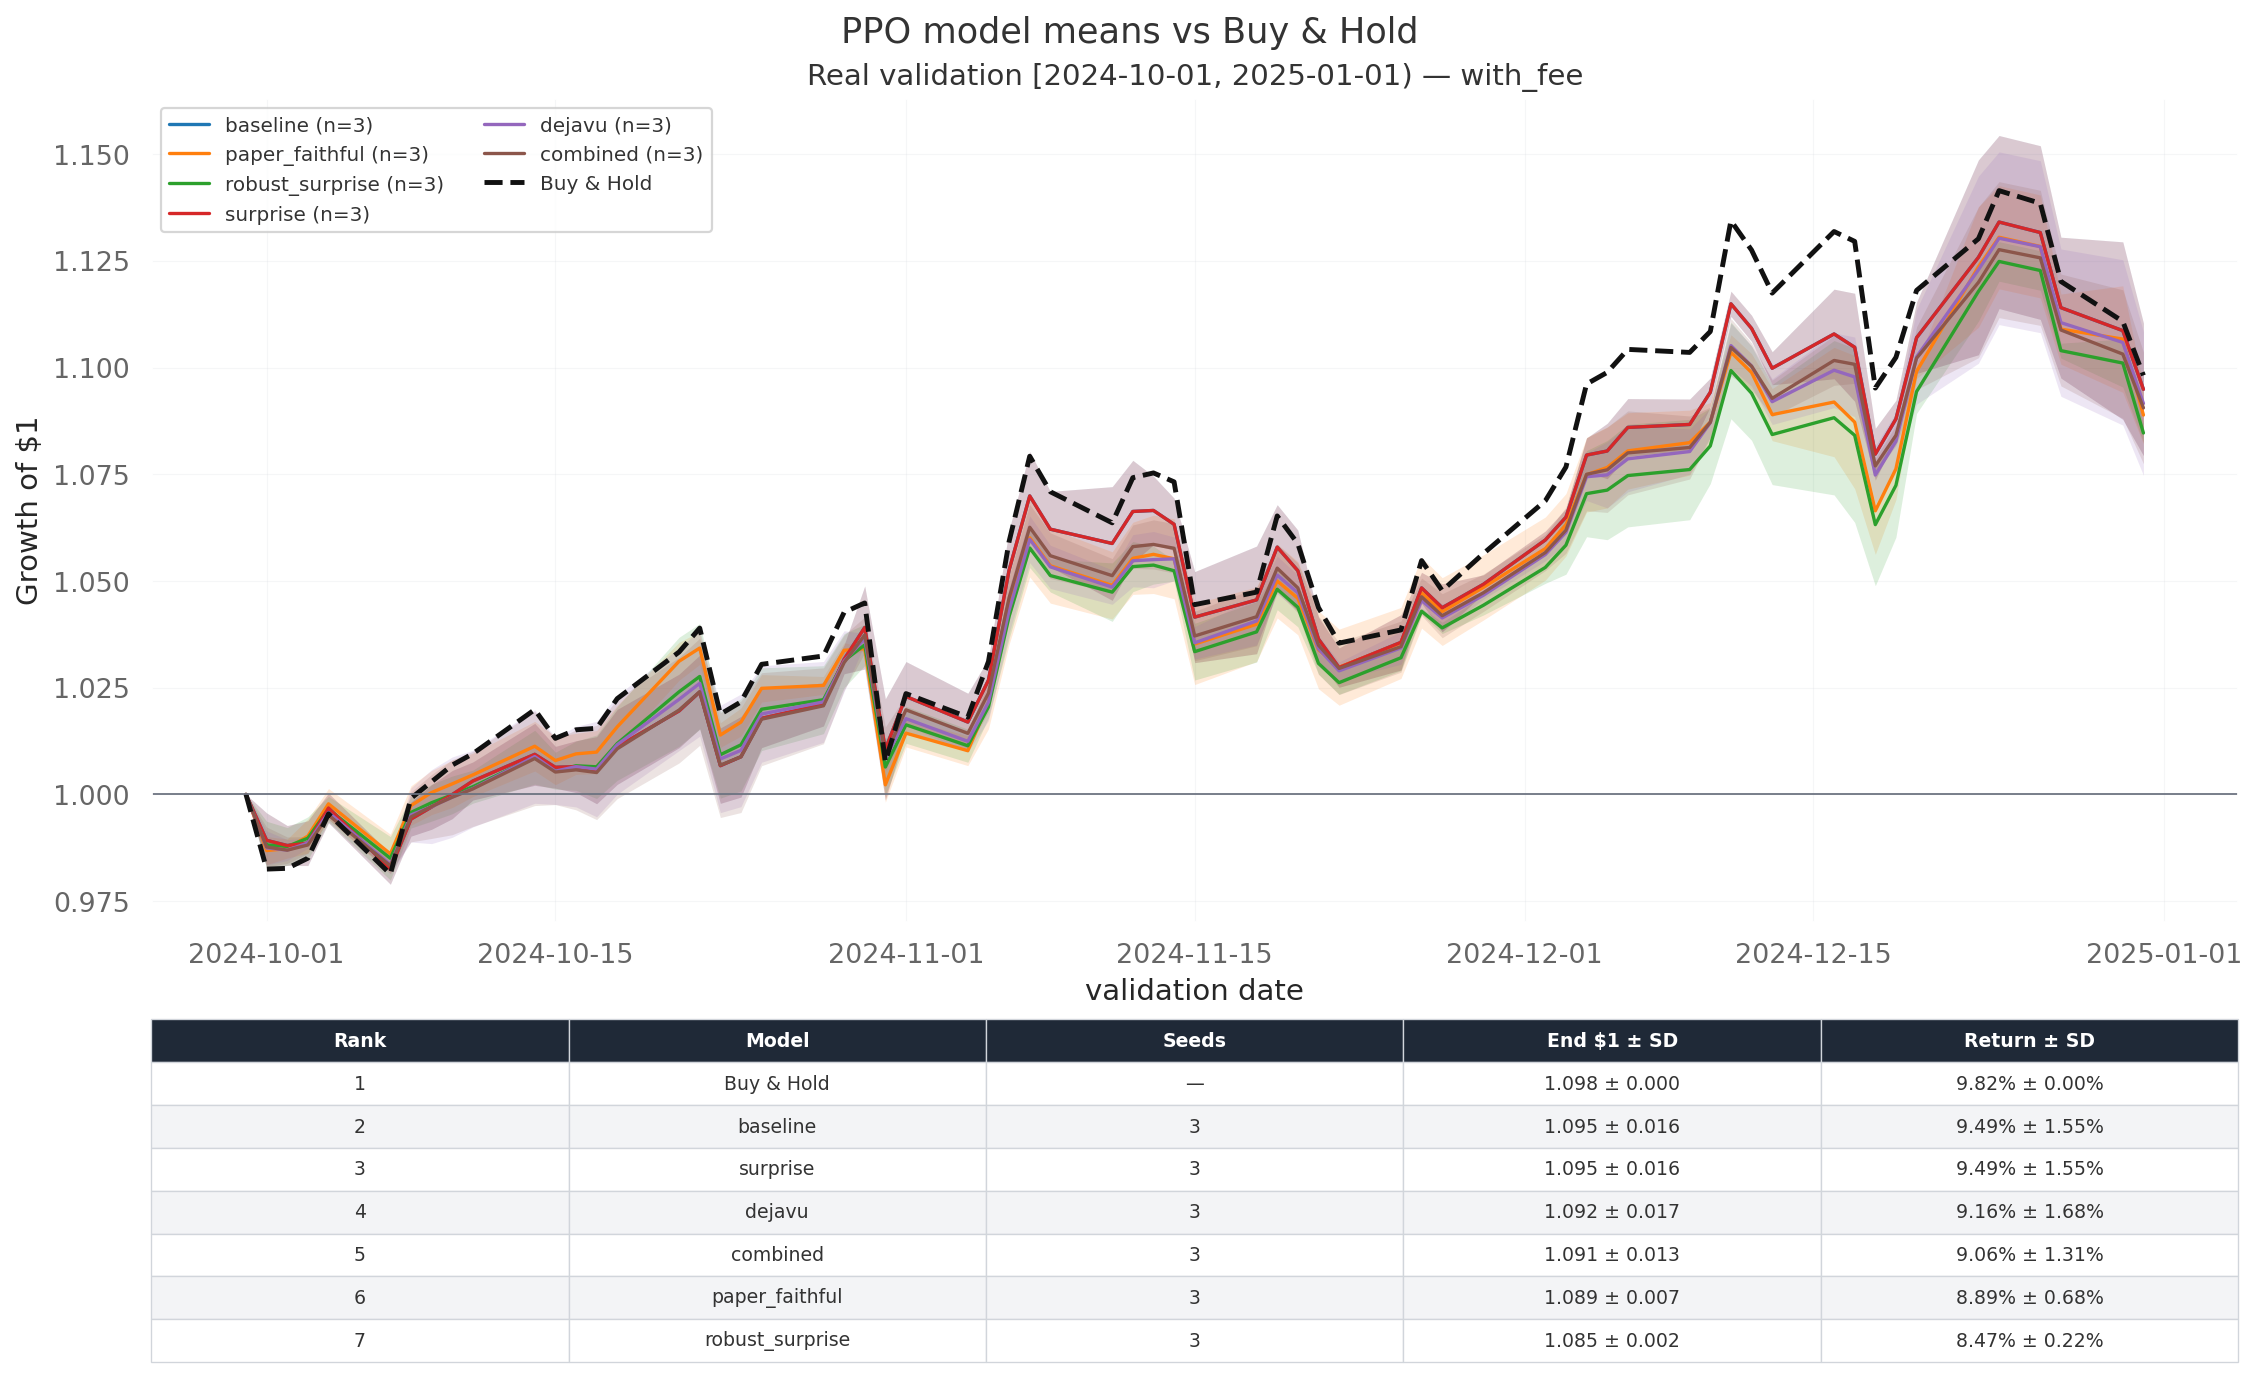

In [22]:
NotebookImage(filename=str(equity_paths[("with_fee", "validation")]))


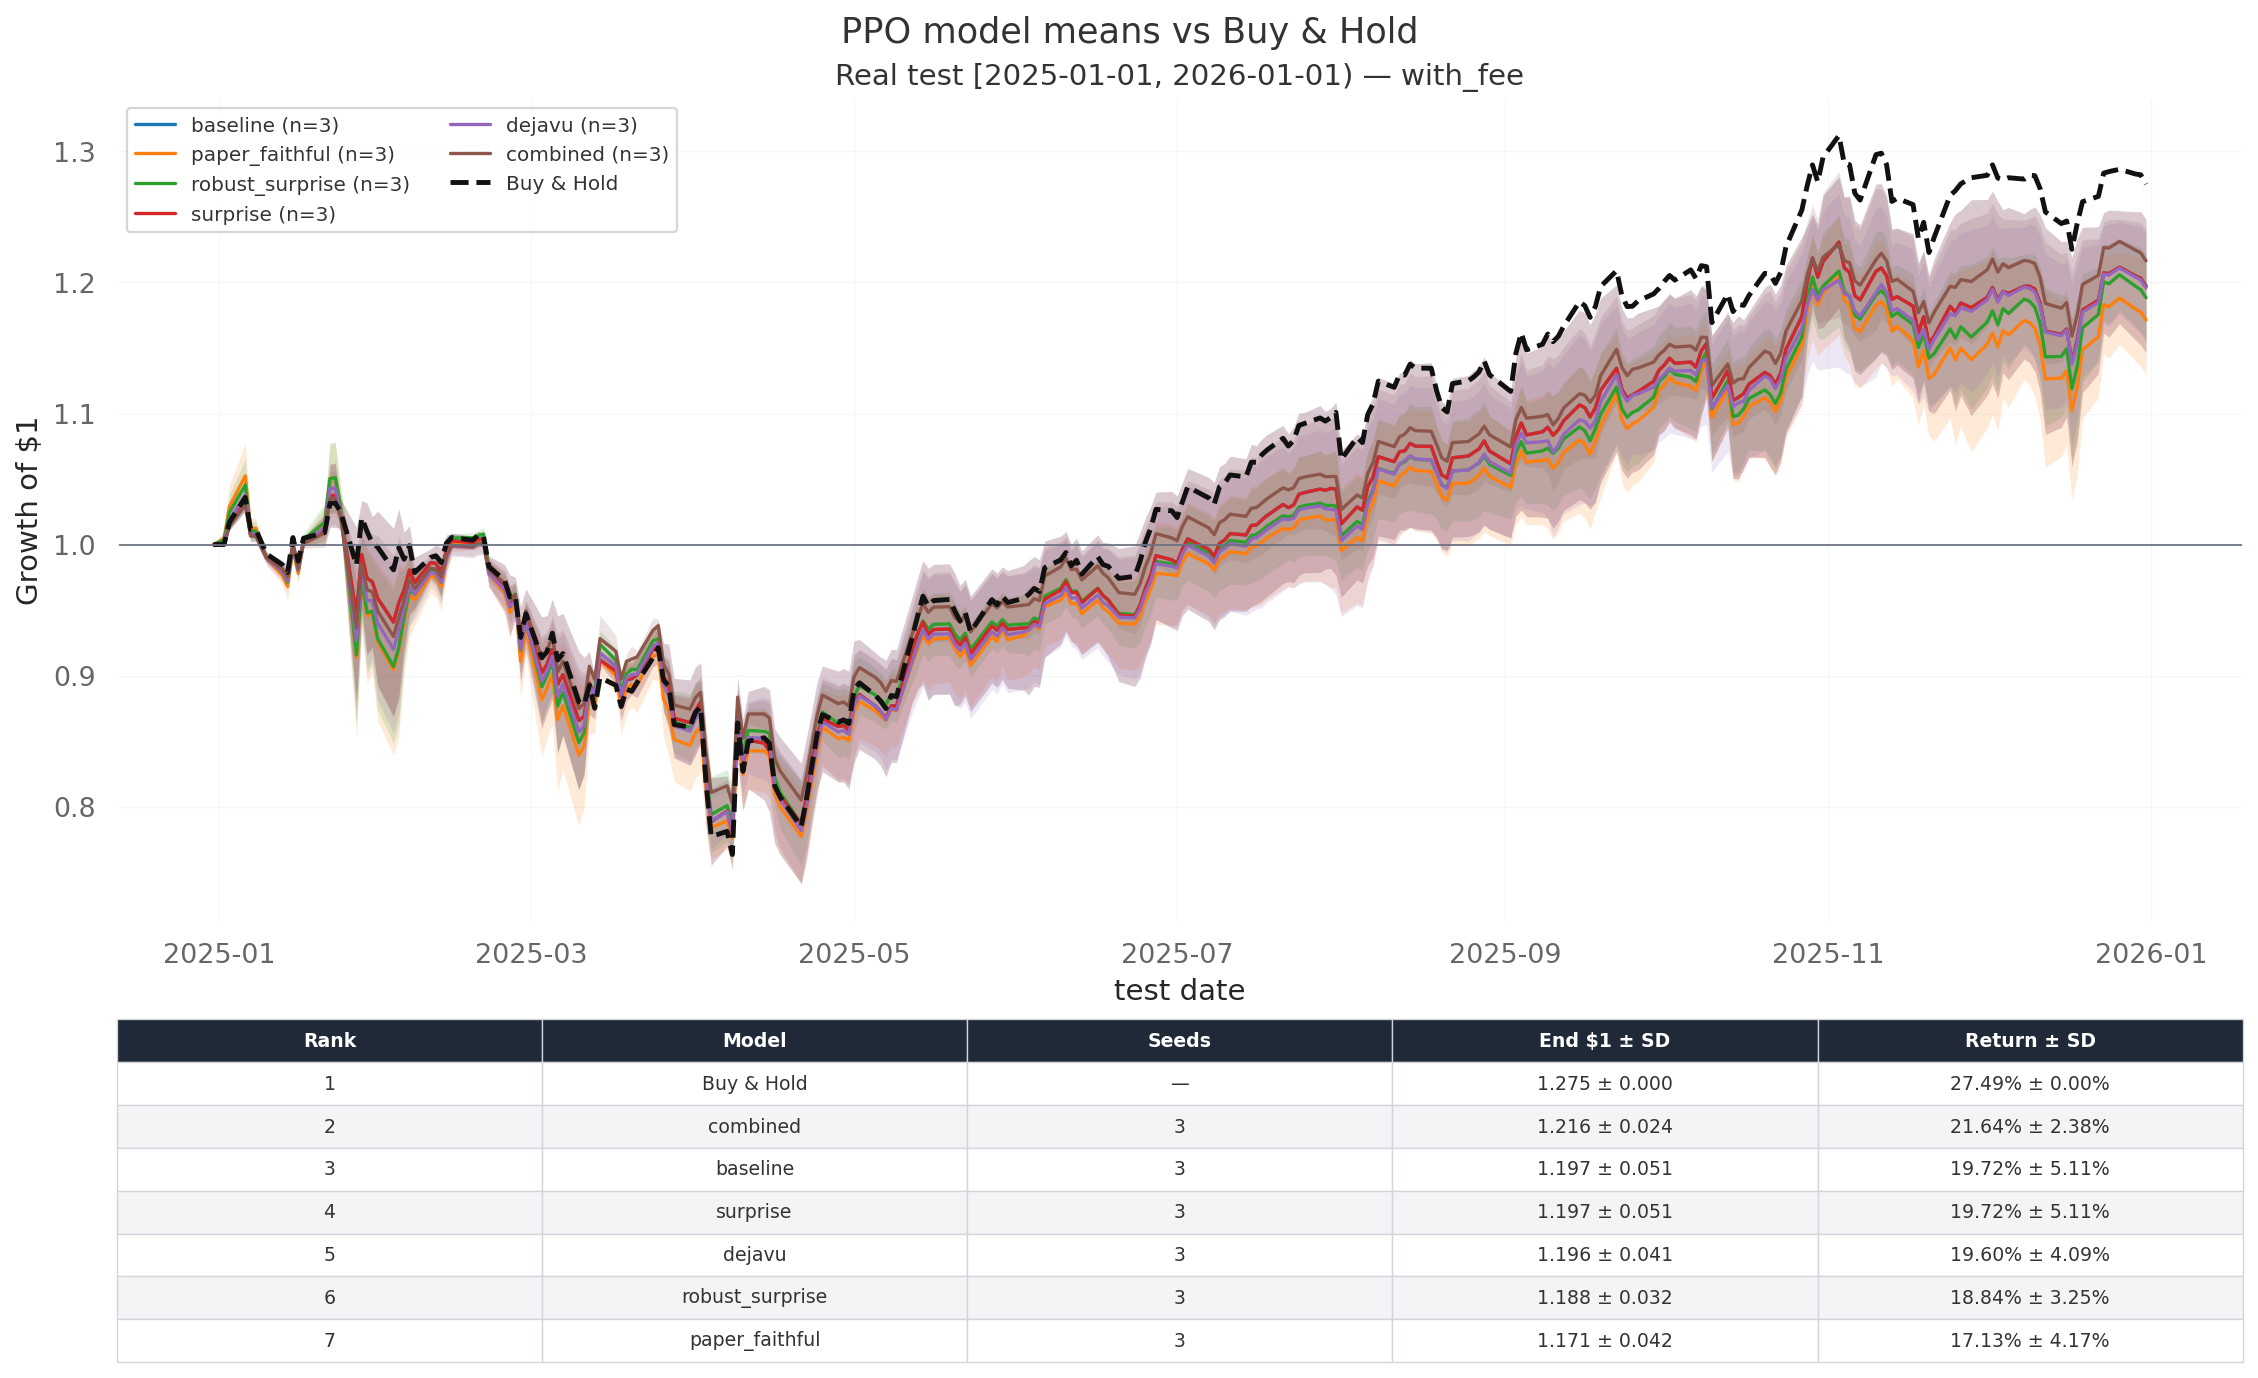

In [23]:
NotebookImage(filename=str(equity_paths[("with_fee", "test")]))


## 8. Portfolio weights

The stacked areas show chosen cash and stock weights through the real test period,
averaged across seeds for each reward variant under the 0.25% fee condition. The
table reports exact mean weights.


In [24]:
weight_paths = {}
weight_summaries = []
for commission_name in COMMISSION_CONFIGS:
    figure, mean_weights = plot_test_portfolio_weights(
        period_results[commission_name]["test"]
    )
    path = ARTIFACT_ROOT / f"{commission_name}__real_test_portfolio_weights.png"
    figure.savefig(path, dpi=160, bbox_inches="tight")
    plt.close(figure)
    mean_weights.insert(1, "commission_name", commission_name)
    weight_summaries.append(mean_weights)
    weight_paths[commission_name] = path
pd.concat(weight_summaries, ignore_index=True).to_csv(
    ARTIFACT_ROOT / "mean_test_portfolio_weights.csv", index=False
)
weight_paths


{'with_fee': PosixPath('/home/cwei1213/FinRL_Exp/results/ppo_portfolio_intrinsic_reward_ablation/full/with_fee__real_test_portfolio_weights.png')}

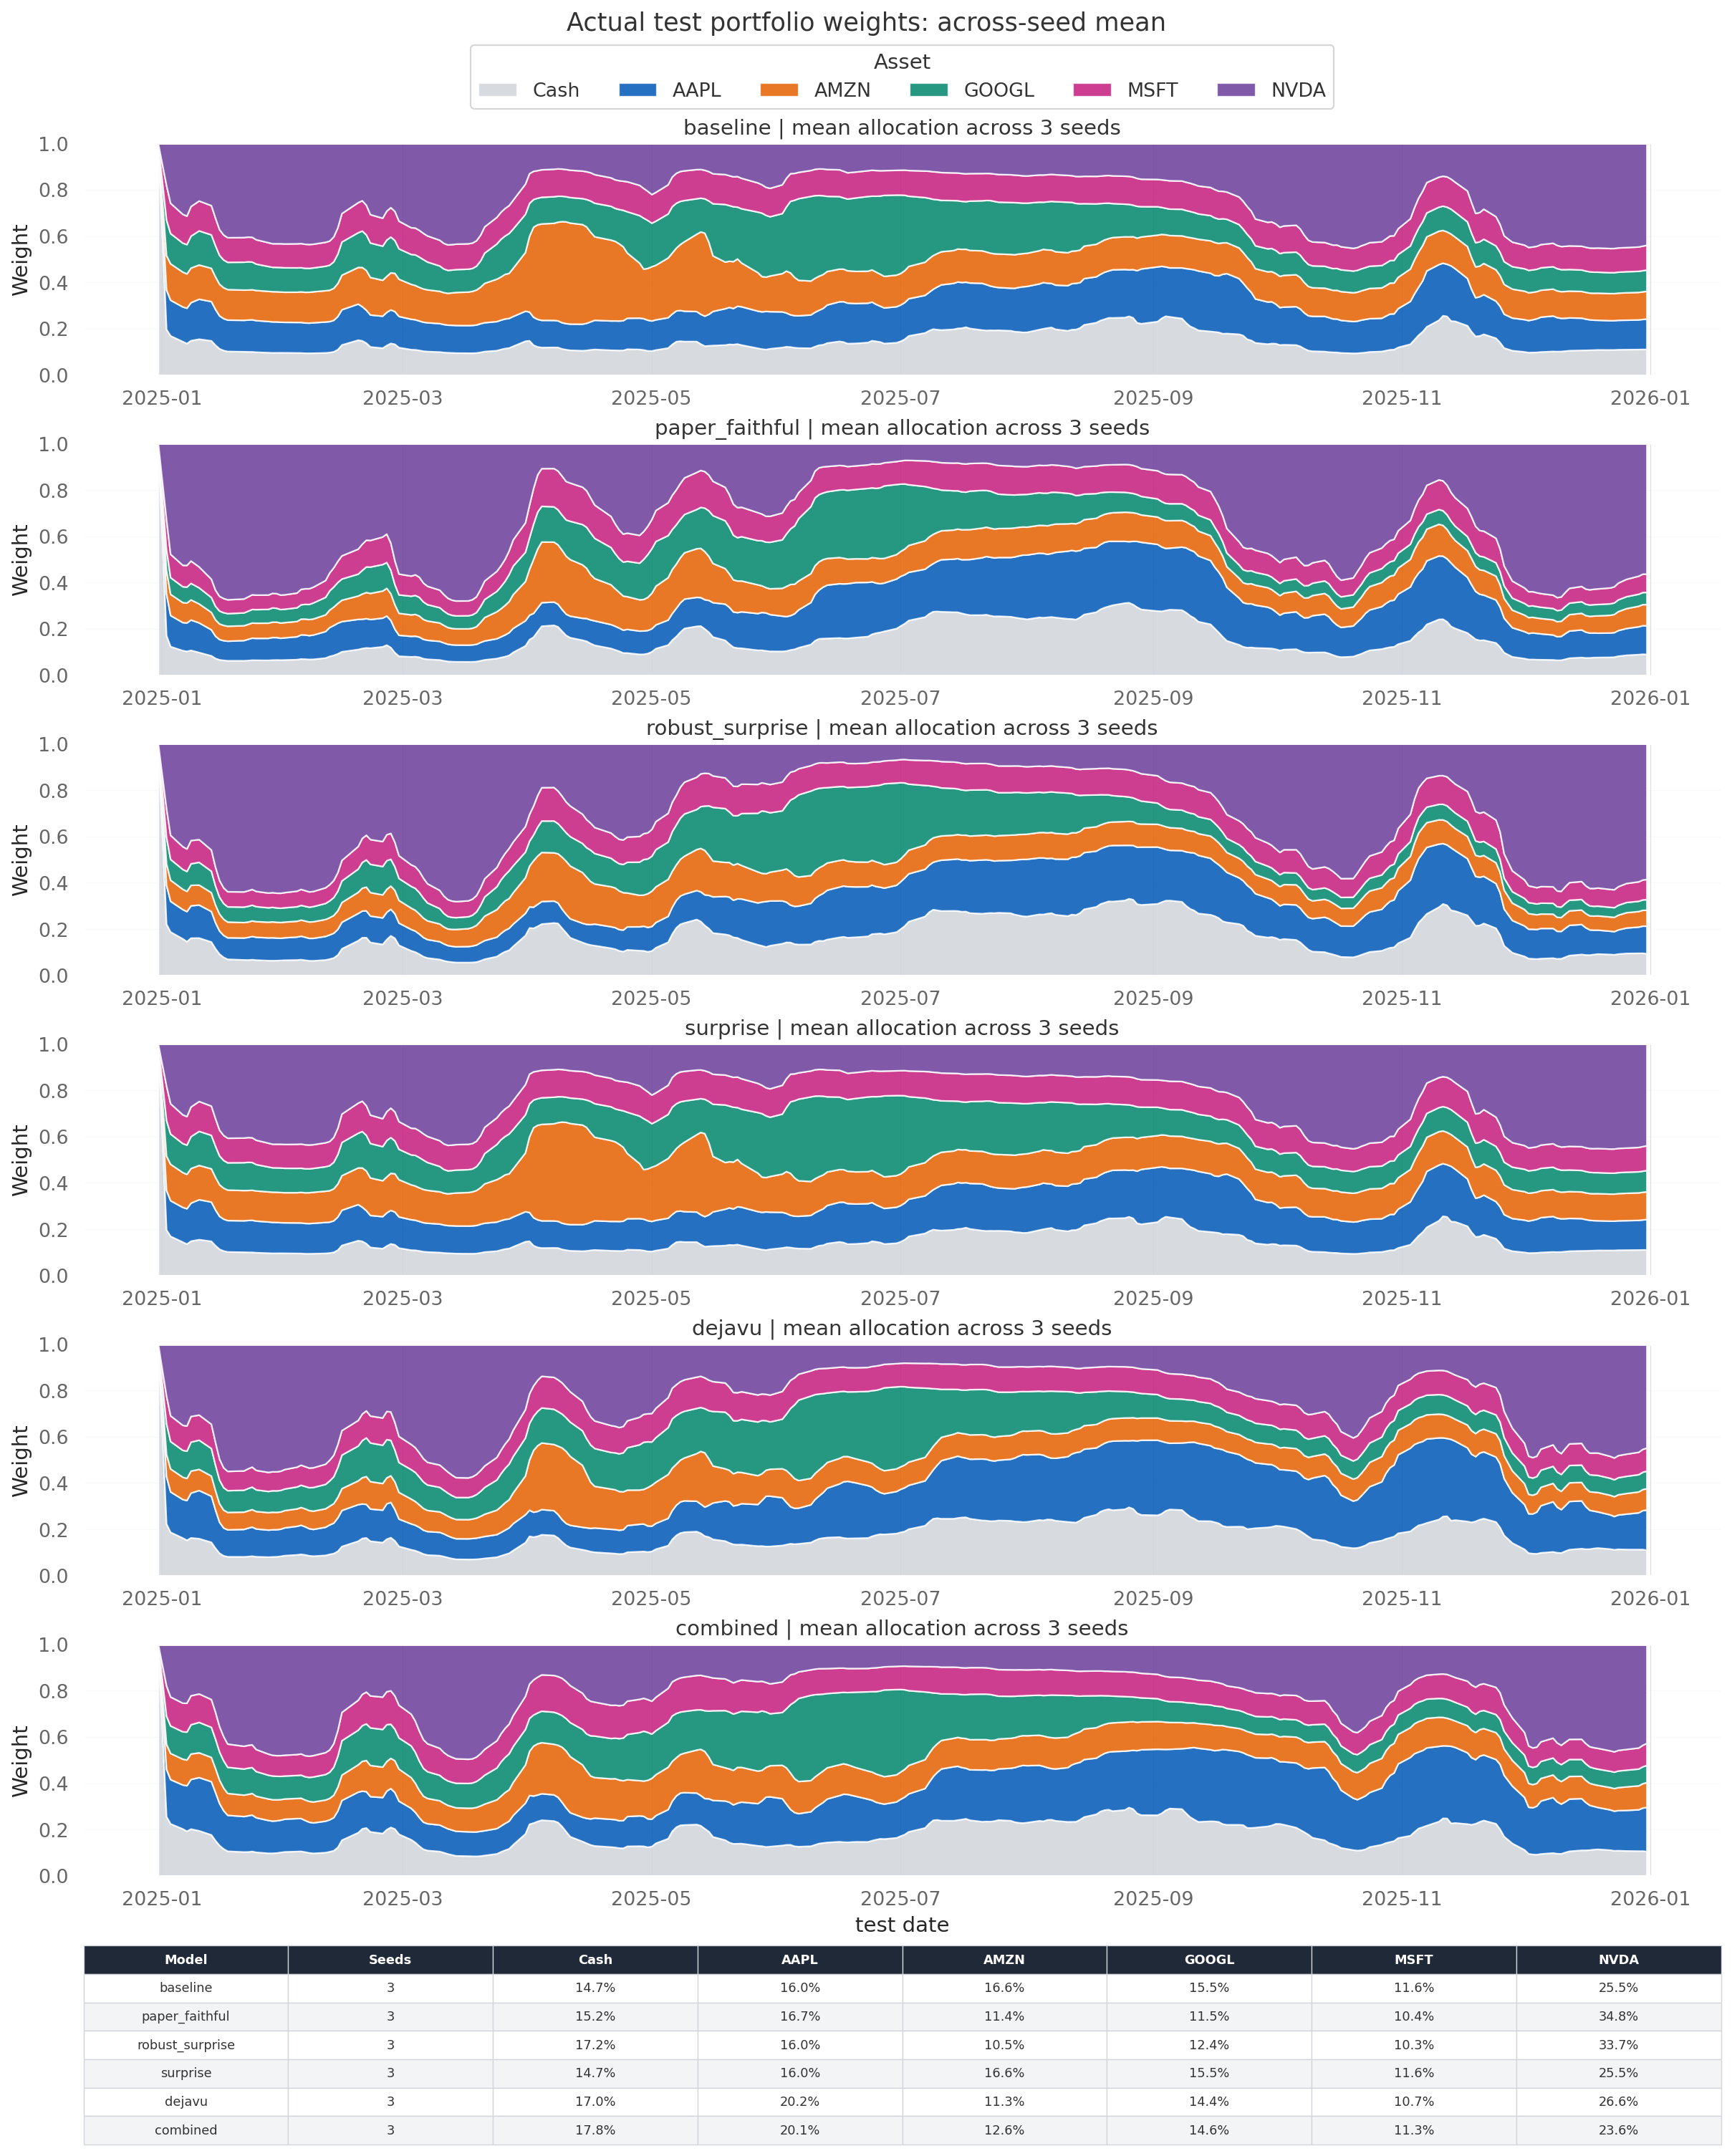

In [25]:
NotebookImage(filename=str(weight_paths["with_fee"]))


## 9. Interpretation checklist

- Compare all variants under the single `with_fee=0.0025` condition.
- Treat `surprise` as the current/legacy implementation, not the robust default.
- Paper-faithful negative rewards or scale spikes are valid stability findings.
- Compare differences with cross-seed bands, not only point estimates.
- Intrinsic diagnostics explain the mechanism; they are not financial P&L.
- Backtest, Sharpe, equity, and portfolio-weight figures use external outcomes only.
- Baseline uses the same real-data PortfolioOptimization + EIIE PPO control; only the
  training reward differs.


## Next steps

Run smoke mode first, then the formal 18-run experiment. The complete intrinsic
controller checkpoint includes its replay pool and can be large. The paper-faithful
variant should always receive a smoke check before a long run because summed Gaussian
NLL may be negative or exhibit large spikes.

```bash
FINRL_INTRINSIC_RUN_MODE=smoke \
FINRL_USE_TRAIN_CACHE=1 \
FINRL_DEVICE=cpu \
jupyter nbconvert --to notebook --execute --inplace \
  examples/FinRL_PortfolioOptimization_PPO_IntrinsicReward_Ablation.ipynb \
  --ExecutePreprocessor.timeout=-1
```

For the formal `6 variants × 3 seeds` experiment, change
`FINRL_INTRINSIC_RUN_MODE=full`.


In [26]:
best_rows = test_model_summary.loc[
    test_model_summary.groupby("commission_name")["sharpe_mean"].idxmax()
]
print("Highest mean PPO Sharpe by commission:")
for _, row in best_rows.iterrows():
    print(
        f"  {row['commission_name']}: {row['variant']} ",
        f"n={int(row['seed_count'])}, ",
        f"Sharpe={row['sharpe_mean']:.3f} ± {row['sharpe_std']:.3f}",
        sep="",
    )
print("Training cache hits:", f"{int(run_table['cache_hit'].sum())}/{len(run_table)}")
print("Treat differences smaller than cross-seed variability cautiously.")


Highest mean PPO Sharpe by commission:
  with_fee: combined n=3, Sharpe=0.896 ± 0.162
Training cache hits: 13/18
Treat differences smaller than cross-seed variability cautiously.
